<a href="https://colab.research.google.com/github/queensss/Algorithms/blob/main/class_balanced_corrected_1st_Final_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



In [ ]:

df = pd.read_csv("/content/bdhs2022_final_analysis_dataset_new.csv")

In [ ]:
df.head()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
0,32.0,156207.0,1.0,111.0,1.0,3.0,2.0,1.0,63.0,2.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4,0.0,0.08
1,18.0,141953.0,2.0,3.0,1.0,2.0,2.0,0.0,56.0,2.0,...,0.0,2.0,1.0,1.0,0.0,0.0,0.0,4,0.0,-1.61
2,14.0,141953.0,2.0,23.0,1.0,3.0,1.0,0.0,NaN,1.0,...,1.0,2.0,1.0,1.0,0.0,1.0,1.0,5,0.0,-1.29
3,NaN,141953.0,2.0,34.0,1.0,3.0,3.0,0.0,46.0,3.0,...,1.0,2.0,1.0,1.0,0.0,0.0,1.0,4,1.0,-2.27
4,5.0,141953.0,2.0,146.0,1.0,2.0,2.0,0.0,24.0,2.0,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,5,0.0,-0.31


In [ ]:
df.tail()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
2486,6.0,699635.0,675.0,31.0,1.0,1.0,4.0,0.0,77.0,4.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2,0.0,-1.92
2487,23.0,699635.0,675.0,41.0,2.0,0.0,2.0,0.0,34.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2,1.0,-3.10
2488,2.0,699635.0,675.0,70.0,1.0,1.0,3.0,0.0,25.0,3.0,...,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1,0.0,-0.47
2489,28.0,699635.0,675.0,70.0,2.0,1.0,2.0,0.0,41.0,3.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,-1.79
2490,12.0,699635.0,675.0,108.0,1.0,2.0,2.0,0.0,34.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,0.0,-1.00


In [ ]:
df.shape

(2491, 27)

In [ ]:
print(df.columns.tolist())

['age_months', 'sample_weight', 'cluster_id', 'hh_id', 'child_line', 'mother_edu', 'birth_order', 'mother_occ', 'birth_interval_months', 'children_ever_born', 'father_edu', 'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean', 'skilled_birth', 'toilet_improved', 'delivery_place_3cat', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'small_at_birth', 'wants_more_children', 'wealth_index_clean', 'stunted', 'haz']


In [ ]:
df.columns.tolist()

['age_months',
 'sample_weight',
 'cluster_id',
 'hh_id',
 'child_line',
 'mother_edu',
 'birth_order',
 'mother_occ',
 'birth_interval_months',
 'children_ever_born',
 'father_edu',
 'division',
 'mother_age',
 'wt',
 'mother_bmi',
 'father_occ_clean',
 'skilled_birth',
 'toilet_improved',
 'delivery_place_3cat',
 'has_tv_clean',
 'has_electricity_clean',
 'reads_newspaper_clean',
 'small_at_birth',
 'wants_more_children',
 'wealth_index_clean',
 'stunted',
 'haz']

# missing value check  
# heatmap

In [ ]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()

# Bar chart

In [ ]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

In [ ]:
df = df.drop(columns=['hh_id', 'cluster_id'])

In [ ]:
df.shape

(2491, 25)

In [ ]:
missing_percent = df.isnull().mean() * 100

In [ ]:
threshold = 30


In [ ]:
df = df.loc[:, missing_percent <= threshold]


In [ ]:
cols_to_drop = missing_percent[missing_percent > 30].index
print(cols_to_drop)


Index(['birth_interval_months'], dtype='object')


In [ ]:
df.shape

(2491, 24)

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['age_months', 'sample_weight', 'child_line', 'mother_edu',
       'birth_order', 'mother_occ', 'children_ever_born', 'father_edu',
       'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean',
       'skilled_birth', 'toilet_improved', 'delivery_place_3cat',
       'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean',
       'small_at_birth', 'wants_more_children', 'wealth_index_clean',
       'stunted', 'haz'],
      dtype='object')

In [ ]:
id_vars = ['cluster_id', 'hh_id', 'child_line']


In [ ]:
numeric_vars = [
   'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]


In [ ]:
all_df_cols = df.columns.tolist()

# Filter id_vars to only include columns that are still in df
current_id_vars = [col for col in id_vars if col in all_df_cols]

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

categorical_vars = list(
    set(all_df_cols) - set(current_id_vars) - set(current_numeric_vars)
)



In [ ]:
print("ID variables:\n", id_vars)
print("\nNumeric variables:\n", numeric_vars)
print("\nCategorical variables:\n", categorical_vars)


ID variables:
 ['cluster_id', 'hh_id', 'child_line']

Numeric variables:
 ['age_months', 'children_ever_born', 'mother_age', 'birth_order', 'mother_bmi']

Categorical variables:
 ['mother_edu', 'father_occ_clean', 'skilled_birth', 'wants_more_children', 'toilet_improved', 'division', 'delivery_place_3cat', 'wealth_index_clean', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'sample_weight', 'haz', 'stunted', 'wt', 'father_edu', 'small_at_birth', 'mother_occ']


# Normality check

In [ ]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.062,0.0,Non-normal
1,children_ever_born,1.200,0.0,Non-normal
2,mother_age,0.543,0.0,Non-normal
3,birth_order,1.207,0.0,Non-normal
4,mother_bmi,0.687,0.0,Non-normal


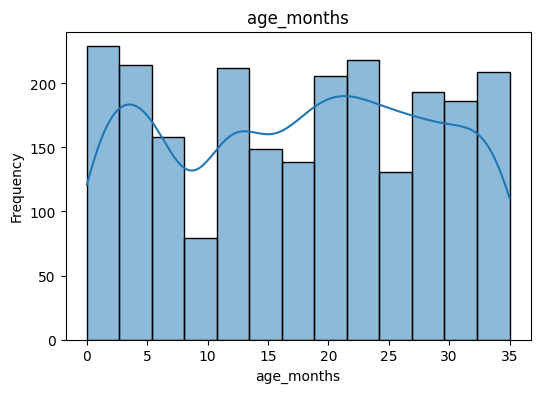

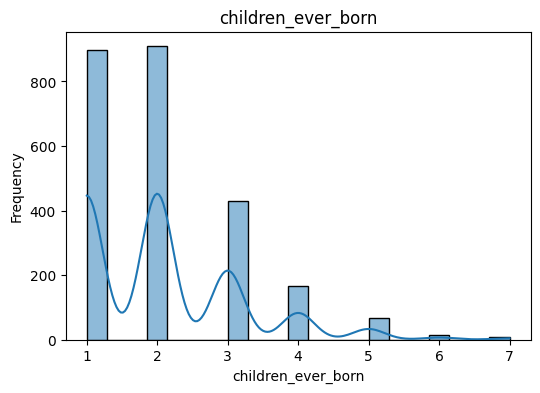

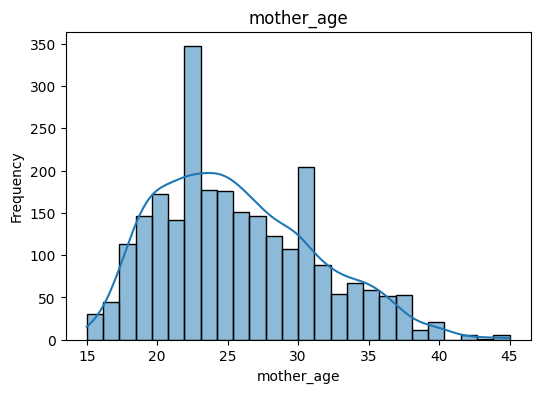

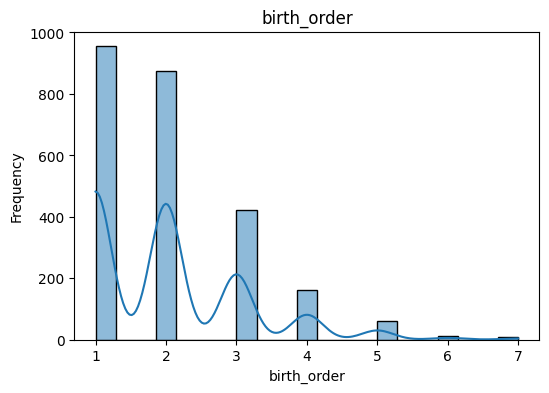

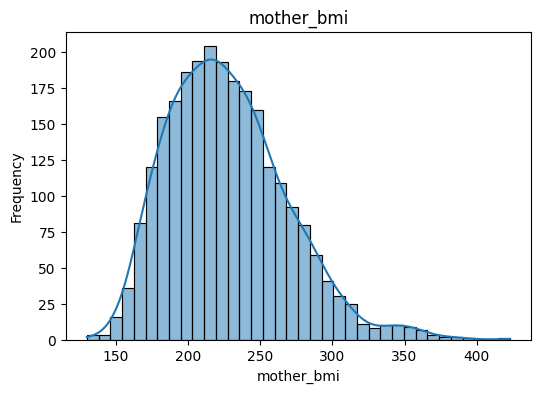

In [ ]:


# List of numeric variables (non-normal)
numeric_cols = [
      'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# MICE PMM

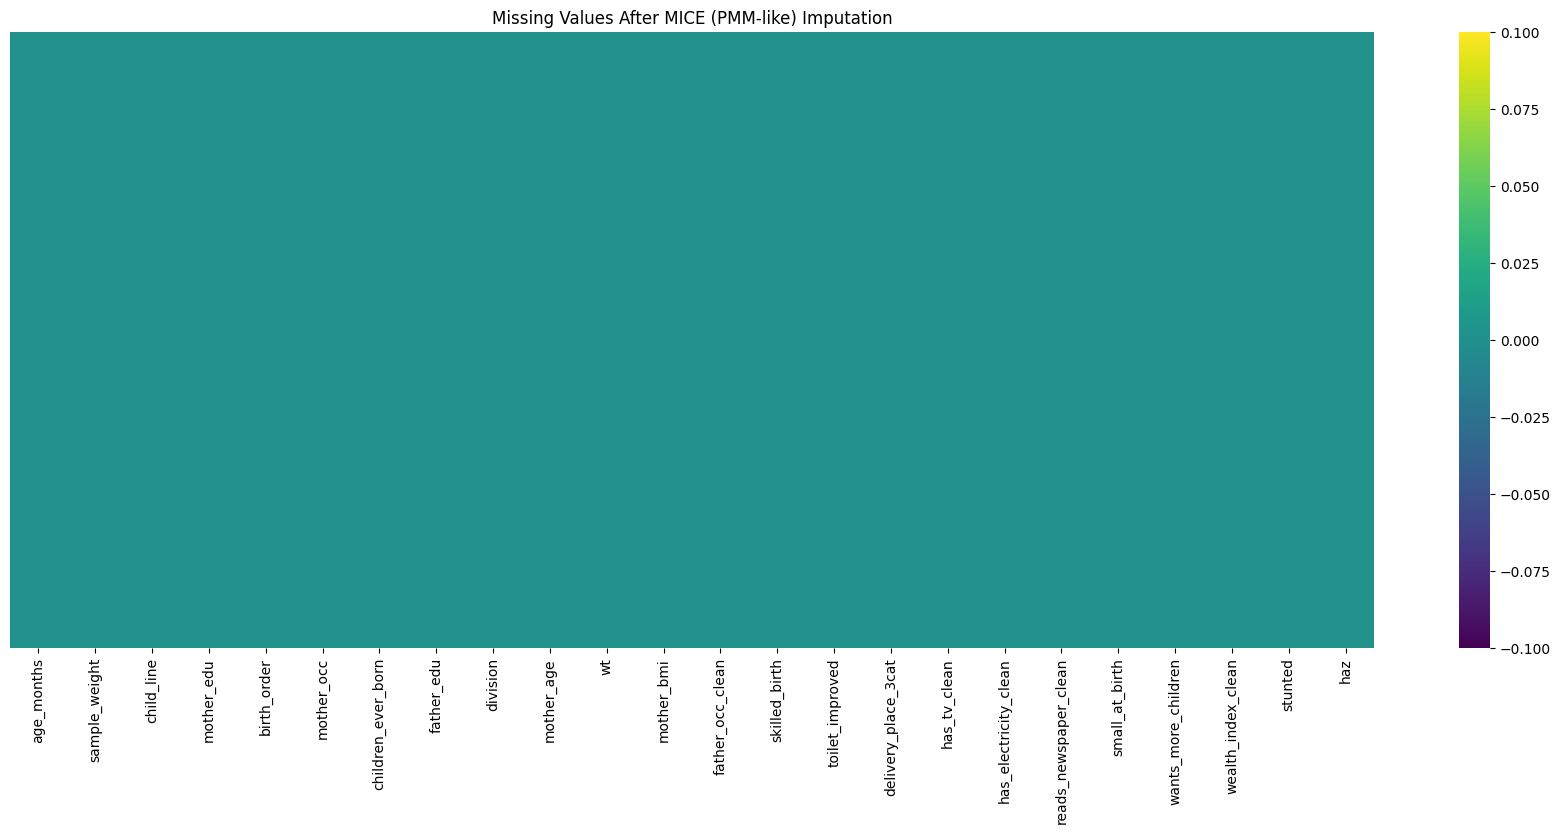

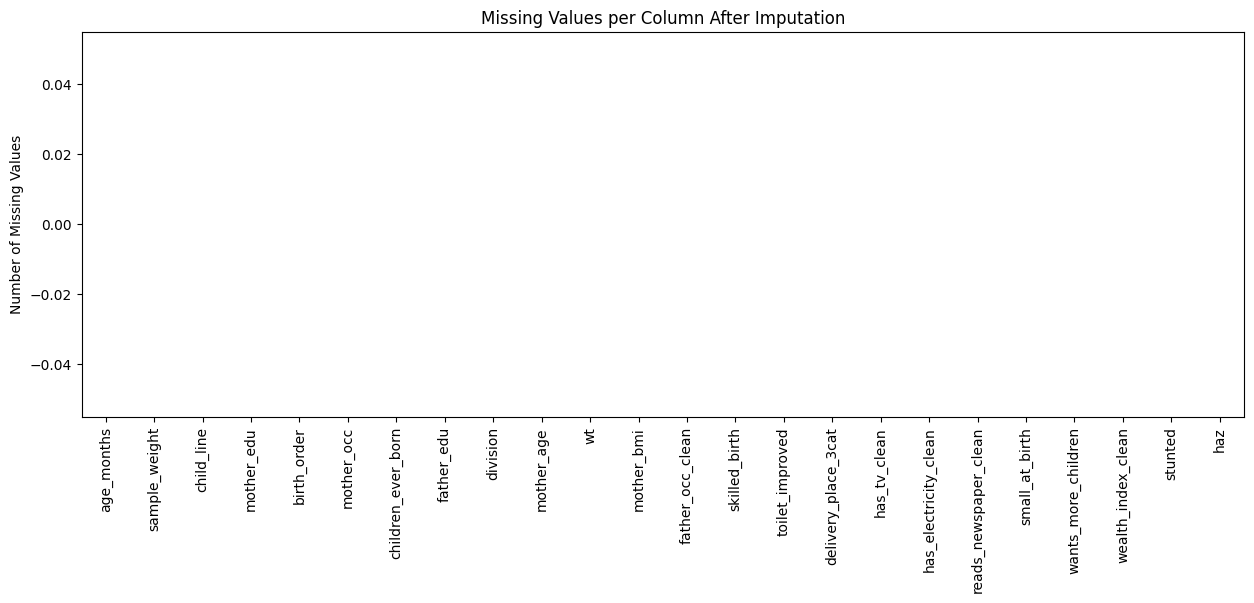

Total missing values after imputation: 0


In [ ]:

# =============================
# Imports (Colab compatible)
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# =============================
# Load data (example)
# =============================
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# =============================
# Define NON-NORMAL variables
# =============================
non_normal_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',]

# =============================
# MICE / PMM-like Imputation
# =============================
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    sample_posterior=True
)

df[non_normal_vars] = mice_imputer.fit_transform(df[non_normal_vars])

# =============================
# Check missing values
# =============================
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title("Missing Values After MICE (PMM-like) Imputation")
plt.show()

df.isnull().sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(15, 5)
)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column After Imputation")
plt.show()

print("Total missing values after imputation:", df.isnull().sum().sum())

In [ ]:
import pandas as pd

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)



                 Variable  Missing_Percent
0              age_months              0.0
1           sample_weight              0.0
2              child_line              0.0
3              mother_edu              0.0
4             birth_order              0.0
5              mother_occ              0.0
6      children_ever_born              0.0
7              father_edu              0.0
8                division              0.0
9              mother_age              0.0
10                     wt              0.0
11             mother_bmi              0.0
12       father_occ_clean              0.0
13          skilled_birth              0.0
14        toilet_improved              0.0
15    delivery_place_3cat              0.0
16           has_tv_clean              0.0
17  has_electricity_clean              0.0
18  reads_newspaper_clean              0.0
19         small_at_birth              0.0
20    wants_more_children              0.0
21     wealth_index_clean              0.0
22         

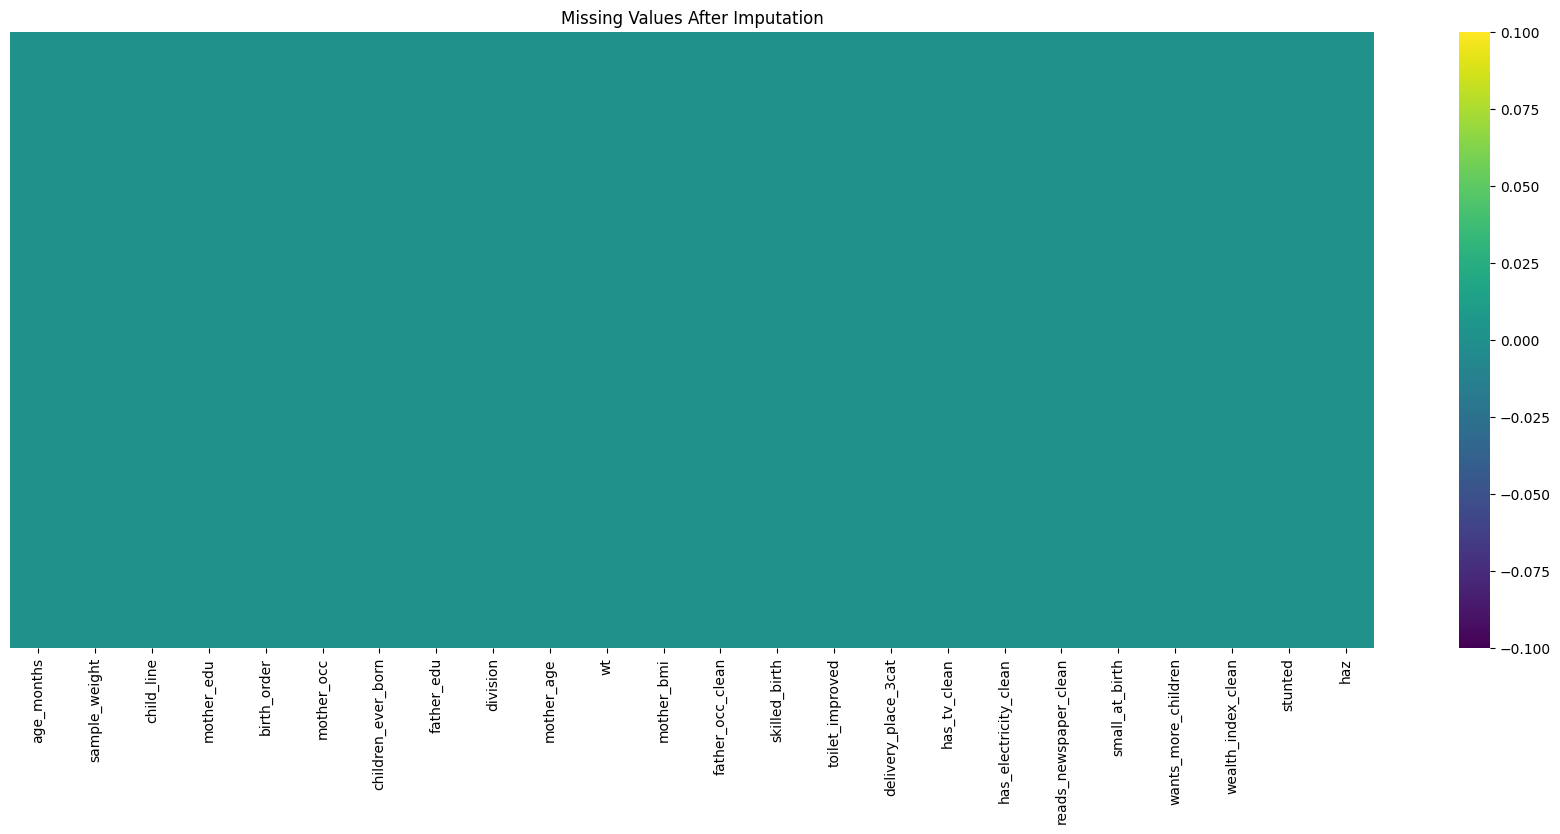

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()


aftre missing value handled we have 24 variable

In [ ]:
df.shape

(2491, 24)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,2491.0,1.758312e+01,10.654874,-5.135347,7.000000,18.000000,2.600000e+01,4.583307e+01
sample_weight,2491.0,1.017775e+06,512971.185567,91325.000000,670684.000000,956806.000000,1.333414e+06,3.891736e+06
child_line,2491.0,1.045363e+00,0.211965,1.000000,1.000000,1.000000,1.000000e+00,3.000000e+00
mother_edu,2491.0,1.867122e+00,0.785158,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
birth_order,2491.0,2.017559e+00,1.078969,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
mother_occ,2491.0,2.079486e-01,0.405921,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
children_ever_born,2491.0,2.063017e+00,1.094907,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
father_edu,2491.0,1.615415e+00,0.970564,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
division,2491.0,3.586511e+00,1.925741,1.000000,2.000000,3.000000,5.000000e+00,7.000000e+00
mother_age,2491.0,2.567041e+01,5.577652,15.000000,21.000000,25.000000,2.900000e+01,4.500000e+01


In [ ]:
# Ensure lists match existing columns
numeric_vars = [col for col in numeric_vars if col in df.columns]
categorical_vars = [col for col in categorical_vars if col in df.columns]

# Convert numeric-coded categorical variables to 'category' type
for col in categorical_vars:
    df[col] = df[col].astype('category')

# Now describe
print(df[numeric_vars].describe())
print(df[categorical_vars].describe())


        age_months  children_ever_born   mother_age  birth_order   mother_bmi
count  2491.000000         2491.000000  2491.000000  2491.000000  2491.000000
mean     17.583119            2.063017    25.670413     2.017559   227.291901
std      10.654874            1.094907     5.577652     1.078969    41.025877
min      -5.135347            1.000000    15.000000     1.000000   130.000000
25%       7.000000            1.000000    21.000000     1.000000   196.500000
50%      18.000000            2.000000    25.000000     2.000000   223.000000
75%      26.000000            3.000000    29.000000     3.000000   251.850000
max      45.833074            7.000000    45.000000     7.000000   422.700000
        mother_edu  father_occ_clean  skilled_birth  wants_more_children  \
count       2491.0            2491.0         2491.0               2491.0   
unique         4.0               6.0            2.0                  2.0   
top            2.0               7.0            1.0                  0

### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot and countplot to understand  the distribution




### Correlation heatmap for Numerical variable.

#boxplot to identify the outlier

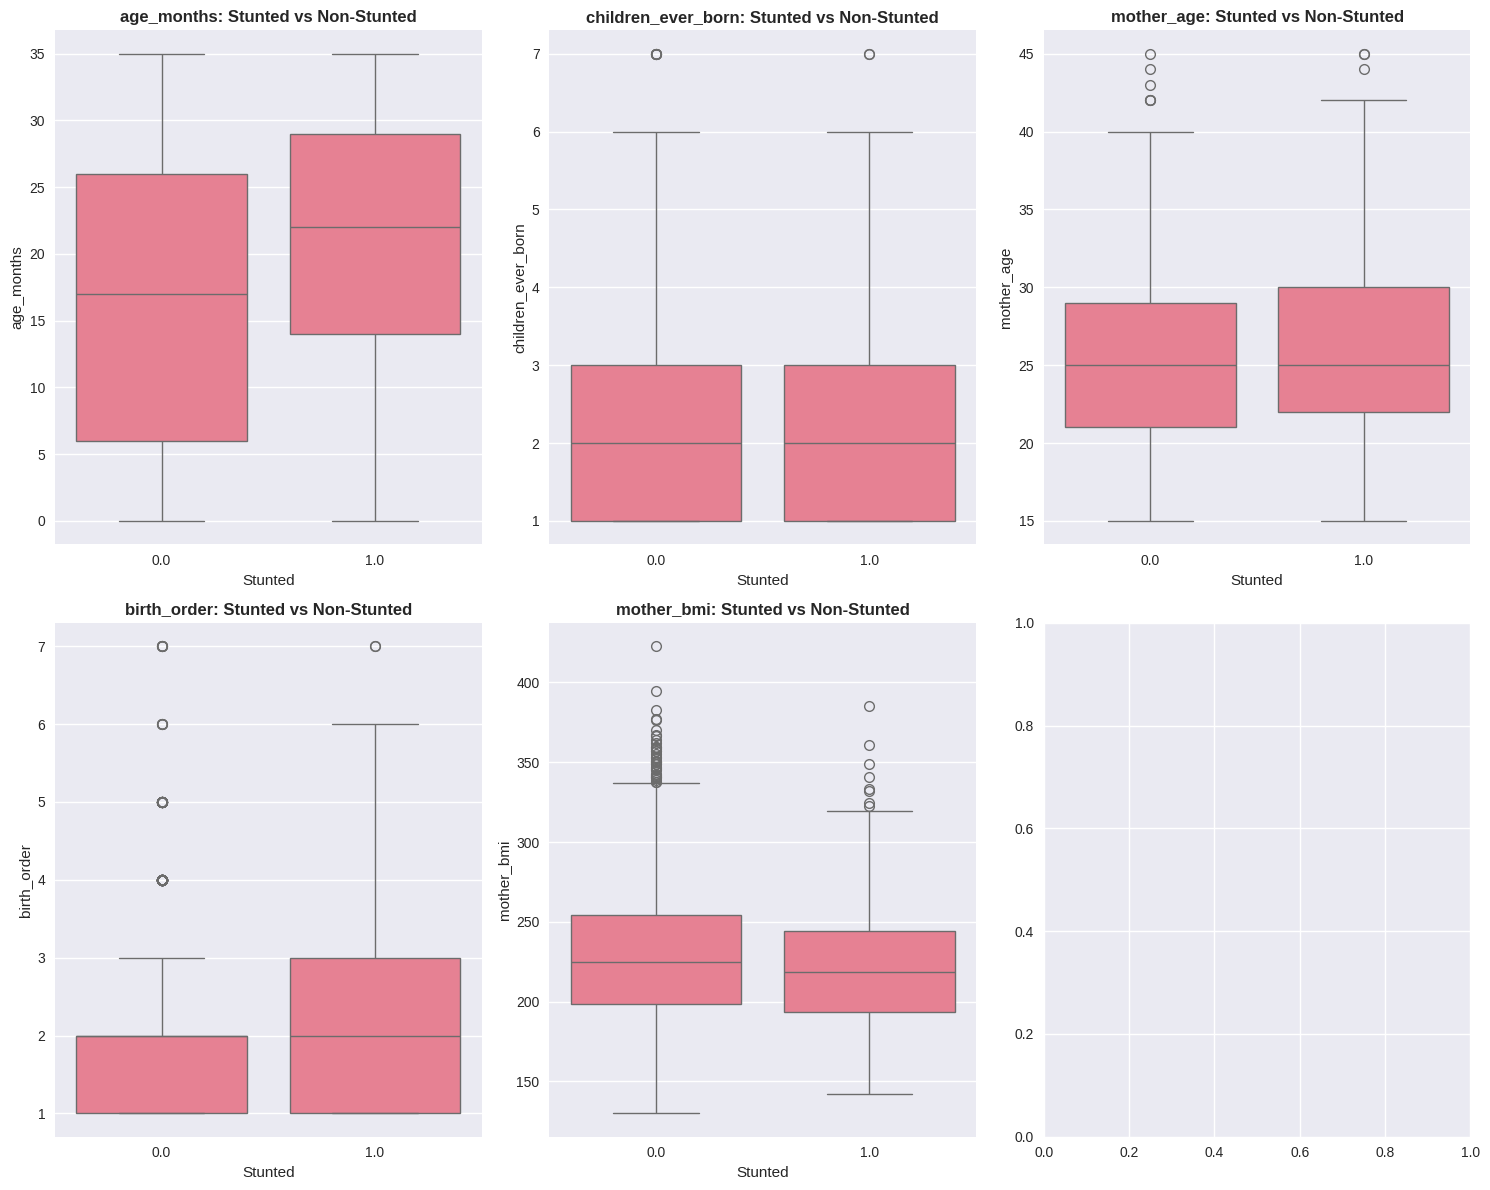

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1A. Stunting vs Key Continuous Variables
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.ravel()

key_vars = [ 'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
   ]

for i, var in enumerate(key_vars):
    sns.boxplot(data=df, x='stunted', y=var, ax=axes[i])
    axes[i].set_title(f'{var}: Stunted vs Non-Stunted', fontweight='bold')
    axes[i].set_xlabel('Stunted')

plt.tight_layout()
plt.show()

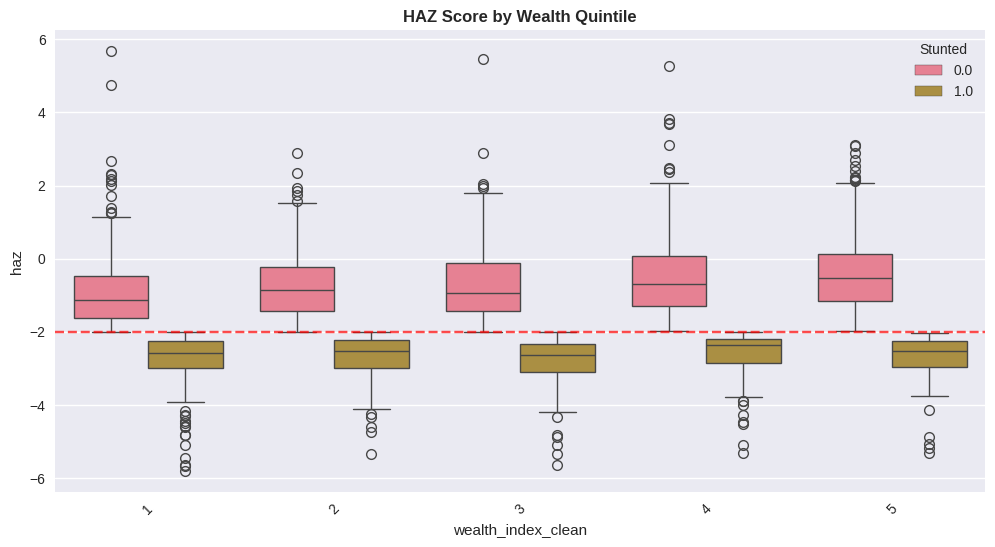

In [ ]:
# 1B. Wealth Quintiles - HAZ Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='wealth_index_clean', y='haz', hue='stunted')
plt.title('HAZ Score by Wealth Quintile', fontweight='bold')
plt.xticks(rotation=45)
plt.axhline(y=-2, color='red', linestyle='--', alpha=0.7)
plt.legend(title='Stunted')
plt.show()

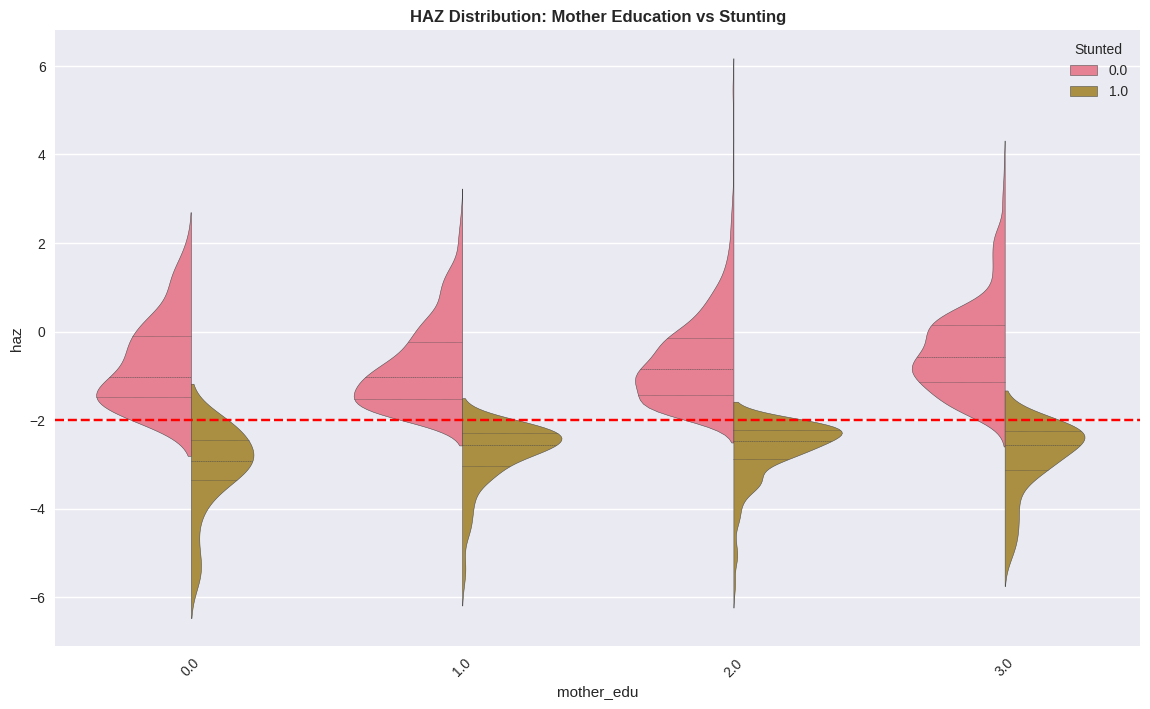

In [ ]:
# Mother Education vs HAZ by Stunting
plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='mother_edu', y='haz', hue='stunted', split=True, inner='quart')
plt.title('HAZ Distribution: Mother Education vs Stunting', fontweight='bold')
plt.xticks(rotation=45)
plt.axhline(y=-2, color='red', linestyle='--')
plt.legend(title='Stunted')
plt.show()

In [ ]:
pip install joypy

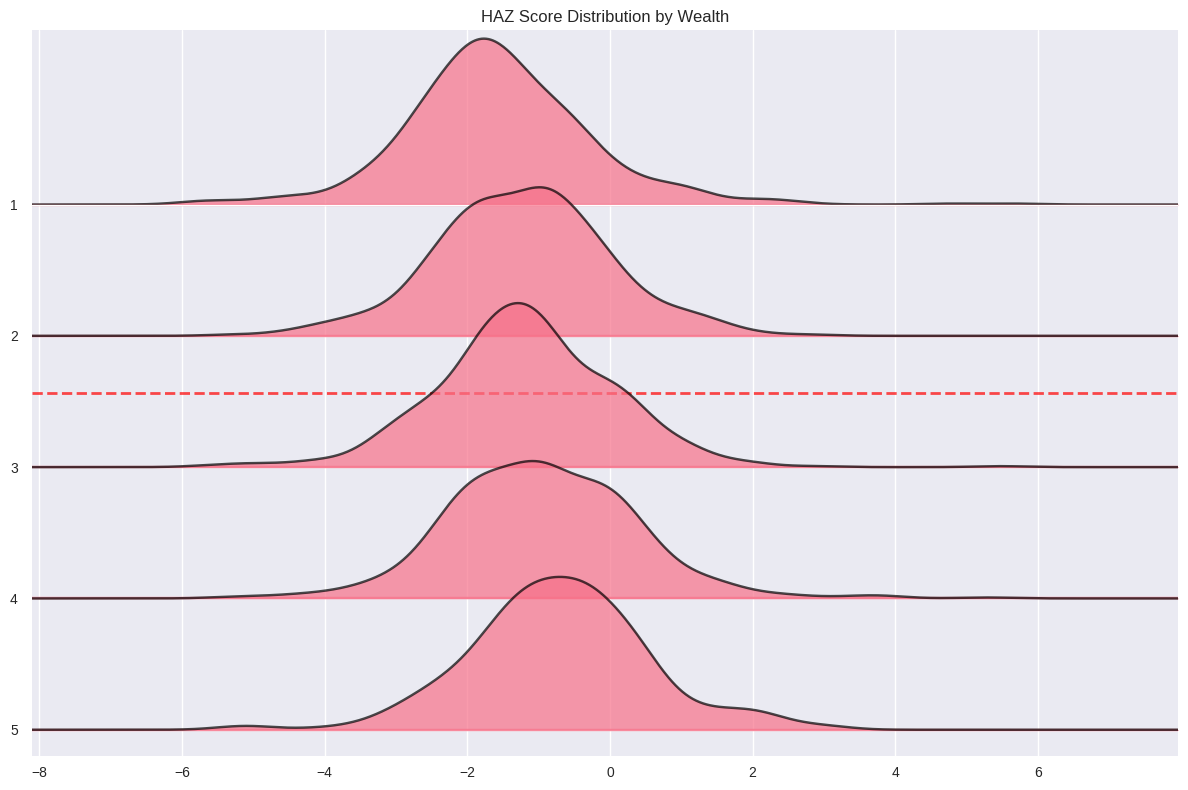

In [ ]:
# Install: pip install joypy
import joypy

# 3A. HAZ by Wealth (Ridgeline)
joypy.joyplot(df, column=['haz'], by='wealth_index_clean',
              figsize=(12, 8), title='HAZ Score Distribution by Wealth',
              grid=True, fill=True, alpha=0.7)
plt.axhline(y=-2, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.show()

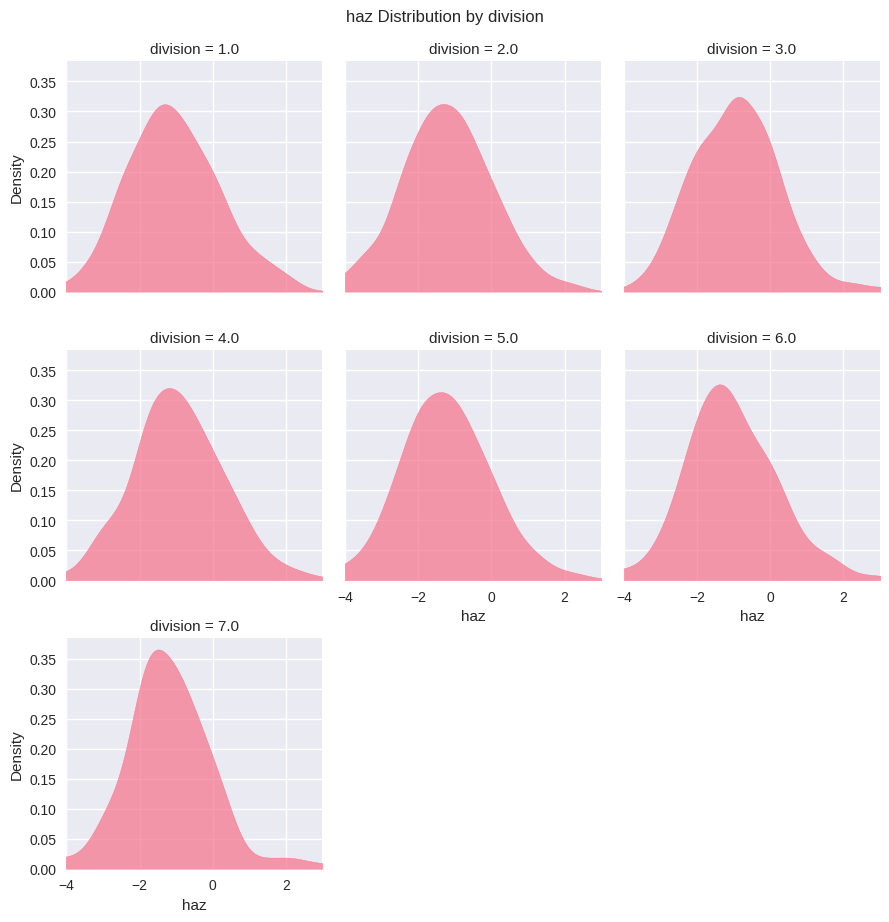

In [ ]:
# 3B. Alternative with seaborn (stacked KDE)
def ridgeline_plot(data, x_col, hue_col, **kwargs):
    grid = sns.FacetGrid(data, col=hue_col, col_wrap=3, height=3, **kwargs)
    grid.map(sns.kdeplot, x_col, fill=True, alpha=0.7)
    grid.fig.suptitle(f'{x_col} Distribution by {hue_col}', y=1.02)
    return grid

ridgeline_plot(df, 'haz', 'division', xlim=(-4, 3))
plt.show()

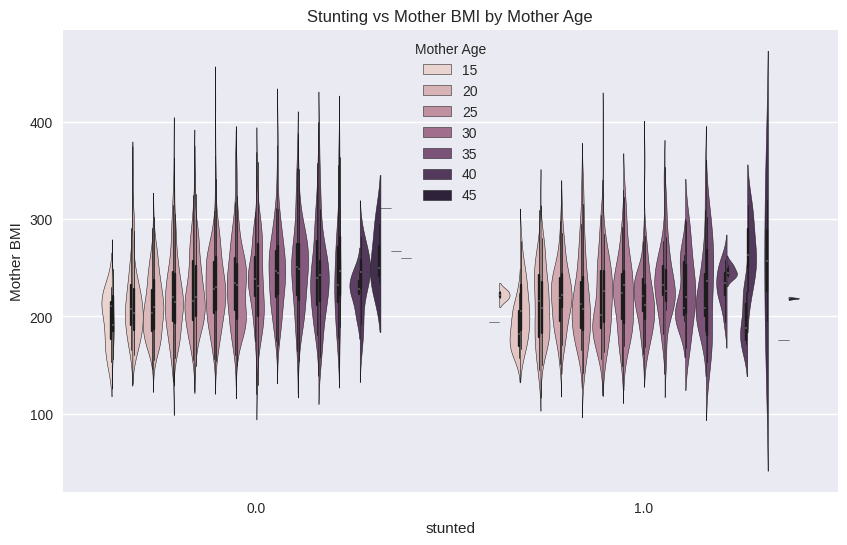

In [ ]:
# 1B. Stunting vs Mother BMI
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='stunted', y='mother_bmi', hue='mother_age', split=True)
plt.title('Stunting vs Mother BMI by Mother Age')
plt.ylabel('Mother BMI')
plt.legend(title='Mother Age')
plt.show()

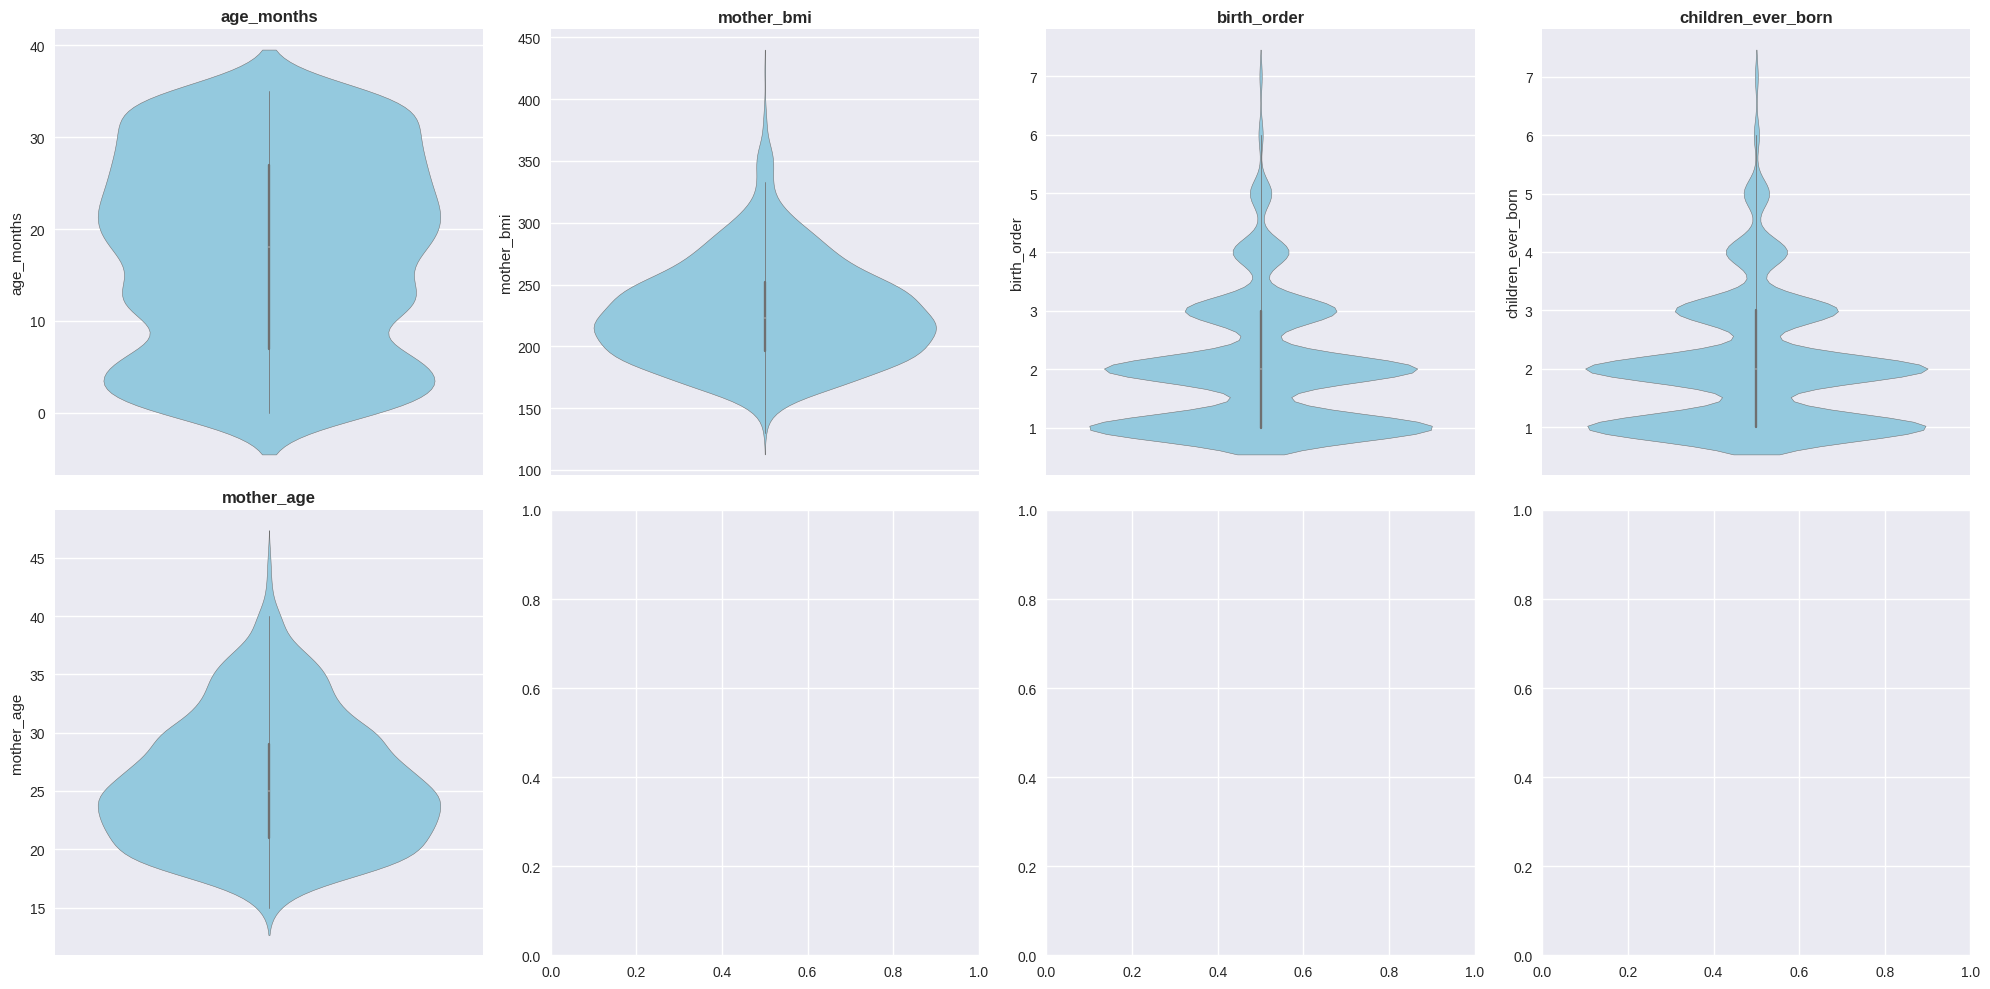

In [ ]:
# Select numerical columns
num_cols = ['age_months',  'mother_bmi',   'birth_order',
            'children_ever_born', 'mother_age']

df_num = df[num_cols].dropna()

# Violin plot grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.violinplot(y=df_num[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

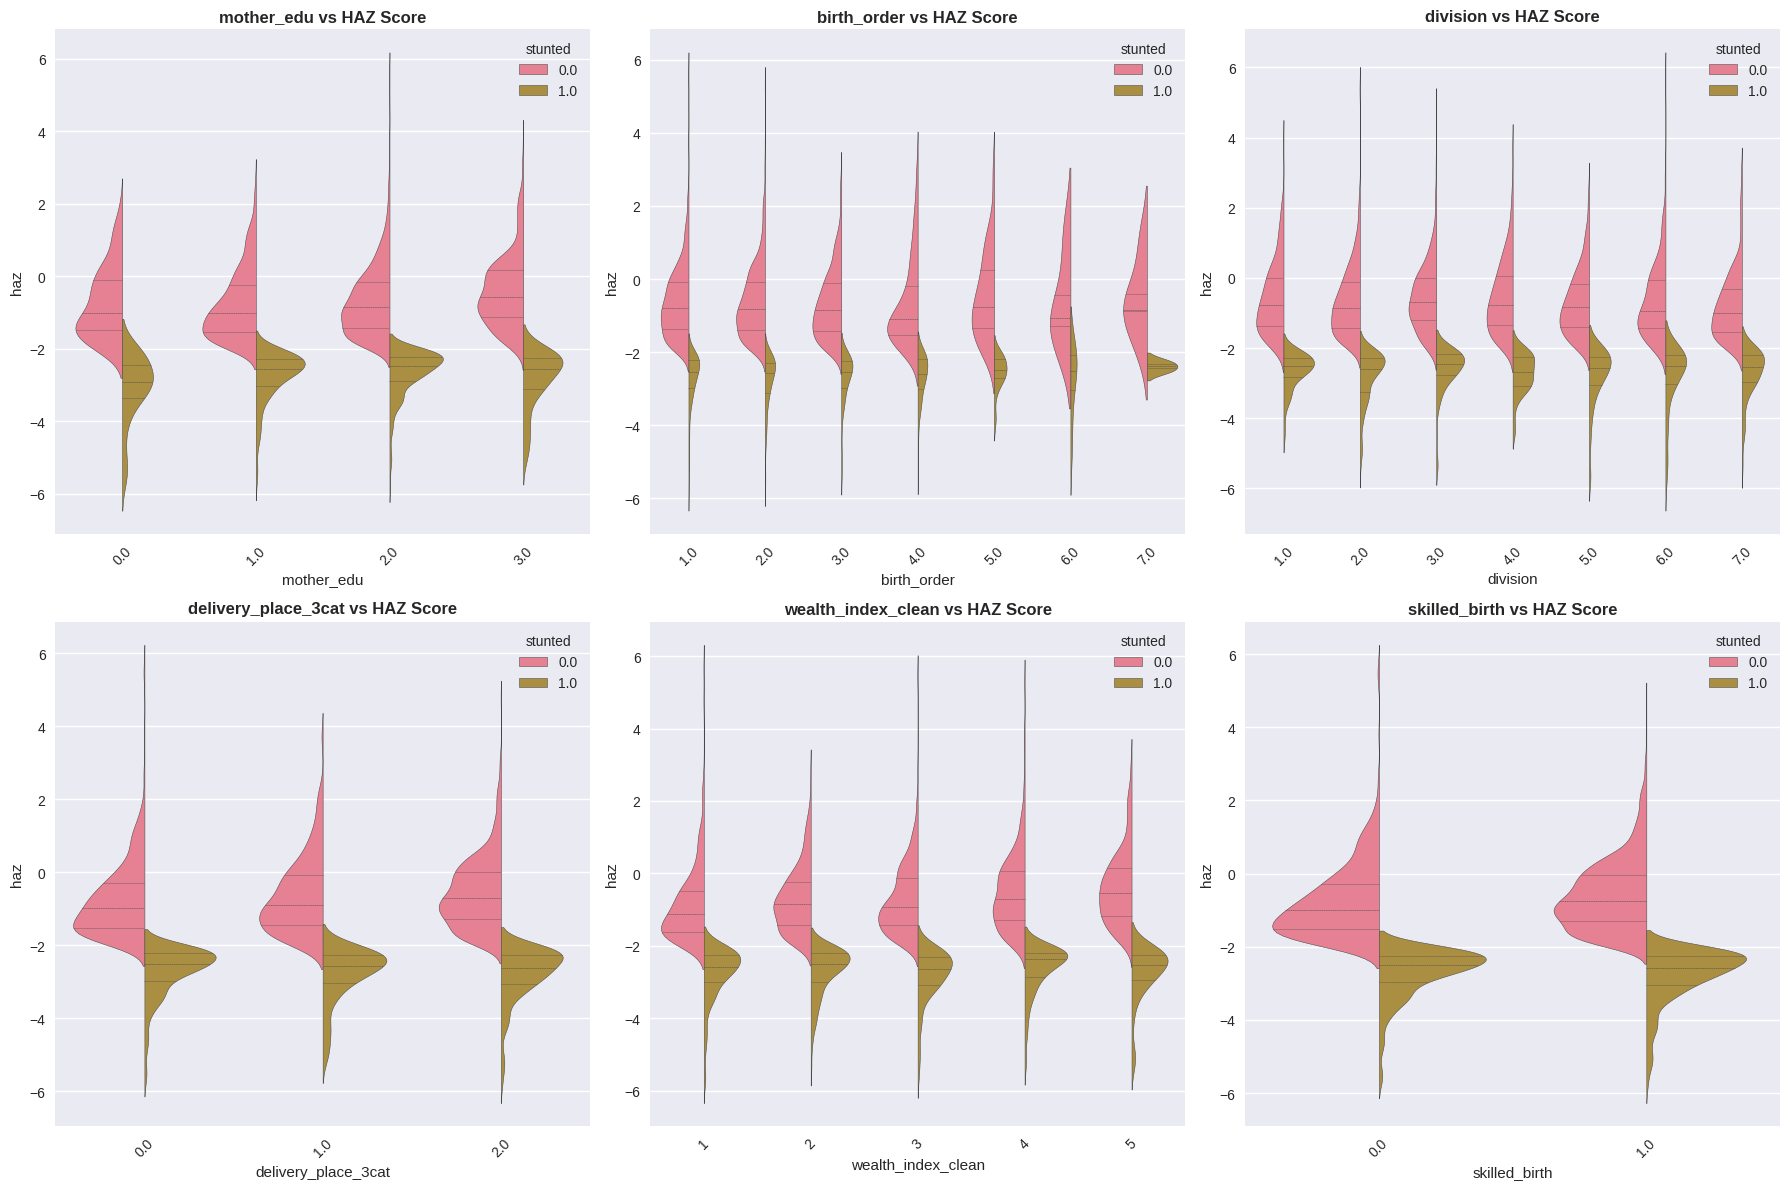

In [ ]:
cat_cols = ['mother_edu', 'birth_order', 'division', 'delivery_place_3cat',
            'wealth_index_clean', 'skilled_birth']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    plt.sca(axes[idx])
    sns.violinplot(data=df, x=col, y='haz', hue='stunted', split=True, inner='quart')
    axes[idx].set_title(f'{col} vs HAZ Score', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

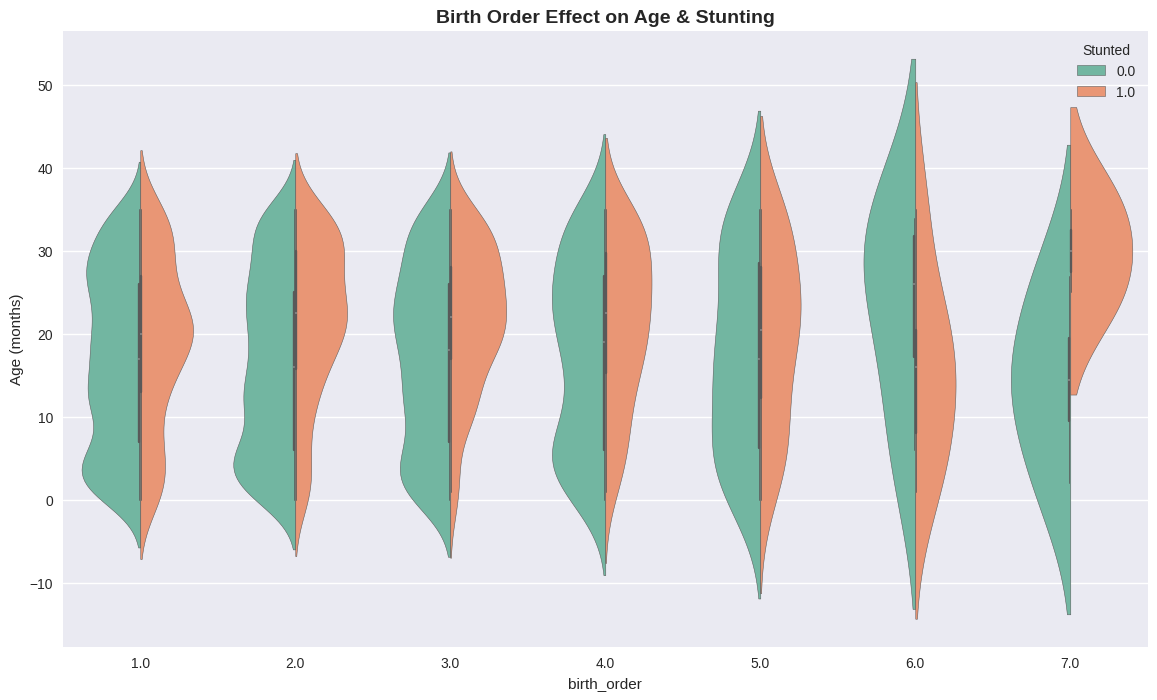

In [ ]:
plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='birth_order', y='age_months', hue='stunted',
               split=True, inner='box', palette='Set2')
plt.title('Birth Order Effect on Age & Stunting', fontsize=14, fontweight='bold')
plt.ylabel('Age (months)')
plt.legend(title='Stunted')
plt.show()

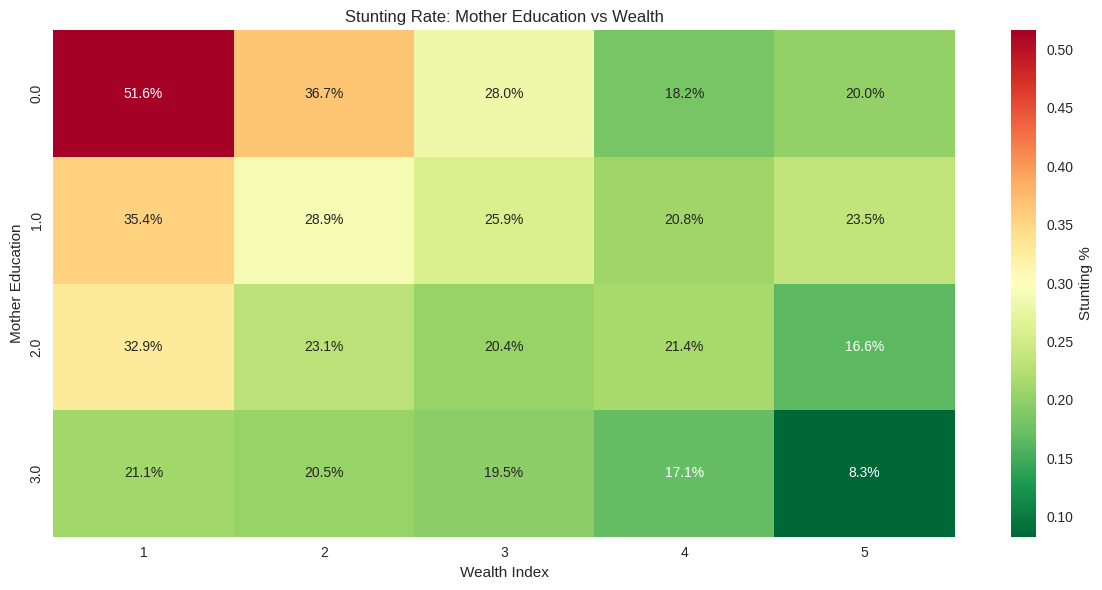

In [ ]:
# Pivot for heatmap
pivot = df.groupby(['mother_edu', 'wealth_index_clean'])['stunted'].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r', cbar_kws={'label': 'Stunting %'})
plt.title('Stunting Rate: Mother Education vs Wealth')
plt.ylabel('Mother Education')
plt.xlabel('Wealth Index')
plt.tight_layout()
plt.show()

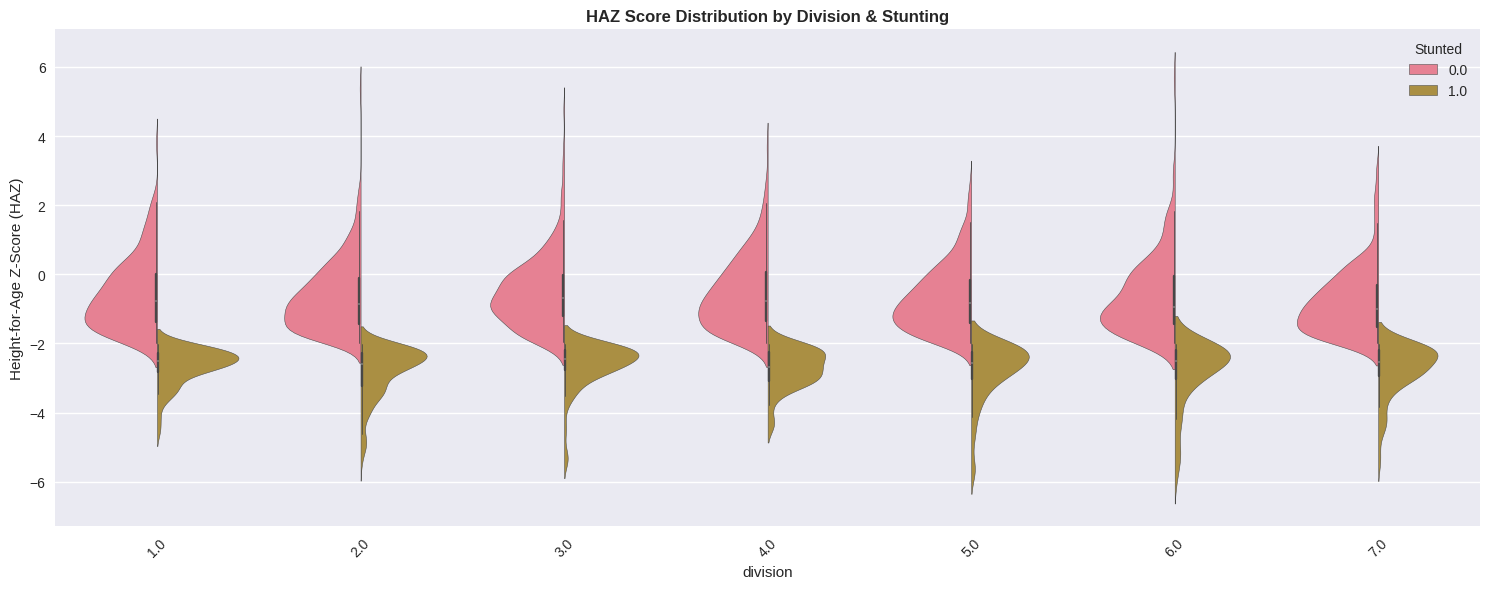

In [ ]:
plt.figure(figsize=(15, 6))
sns.violinplot(data=df, x='division', y='haz', hue='stunted', split=True)
plt.title('HAZ Score Distribution by Division & Stunting', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Height-for-Age Z-Score (HAZ)')
plt.legend(title='Stunted')
plt.tight_layout()
plt.show()

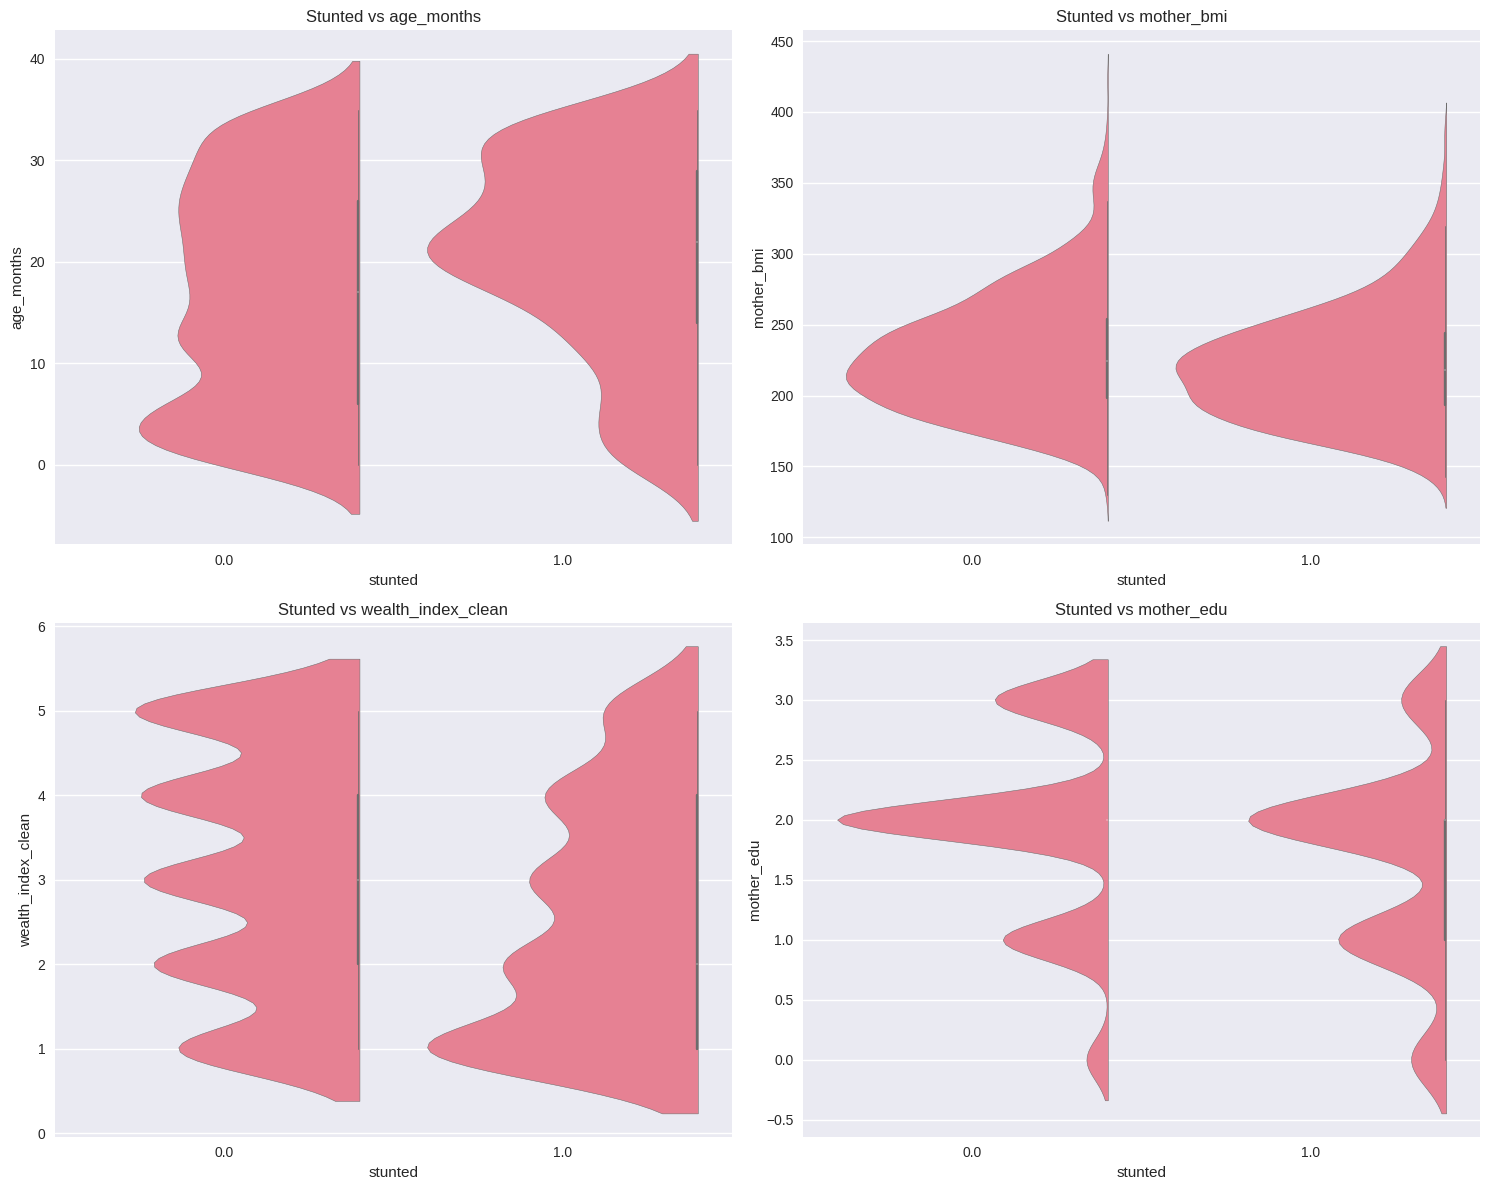

In [ ]:
# One-liner for all key relationships
key_plots = ['age_months', 'mother_bmi', 'wealth_index_clean', 'mother_edu']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, var in enumerate(key_plots):
    row, col = i//2, i%2
    sns.violinplot(data=df, x='stunted', y=var, ax=axes[row,col], split=True)
    axes[row,col].set_title(f'Stunted vs {var}')

plt.tight_layout()
plt.show()

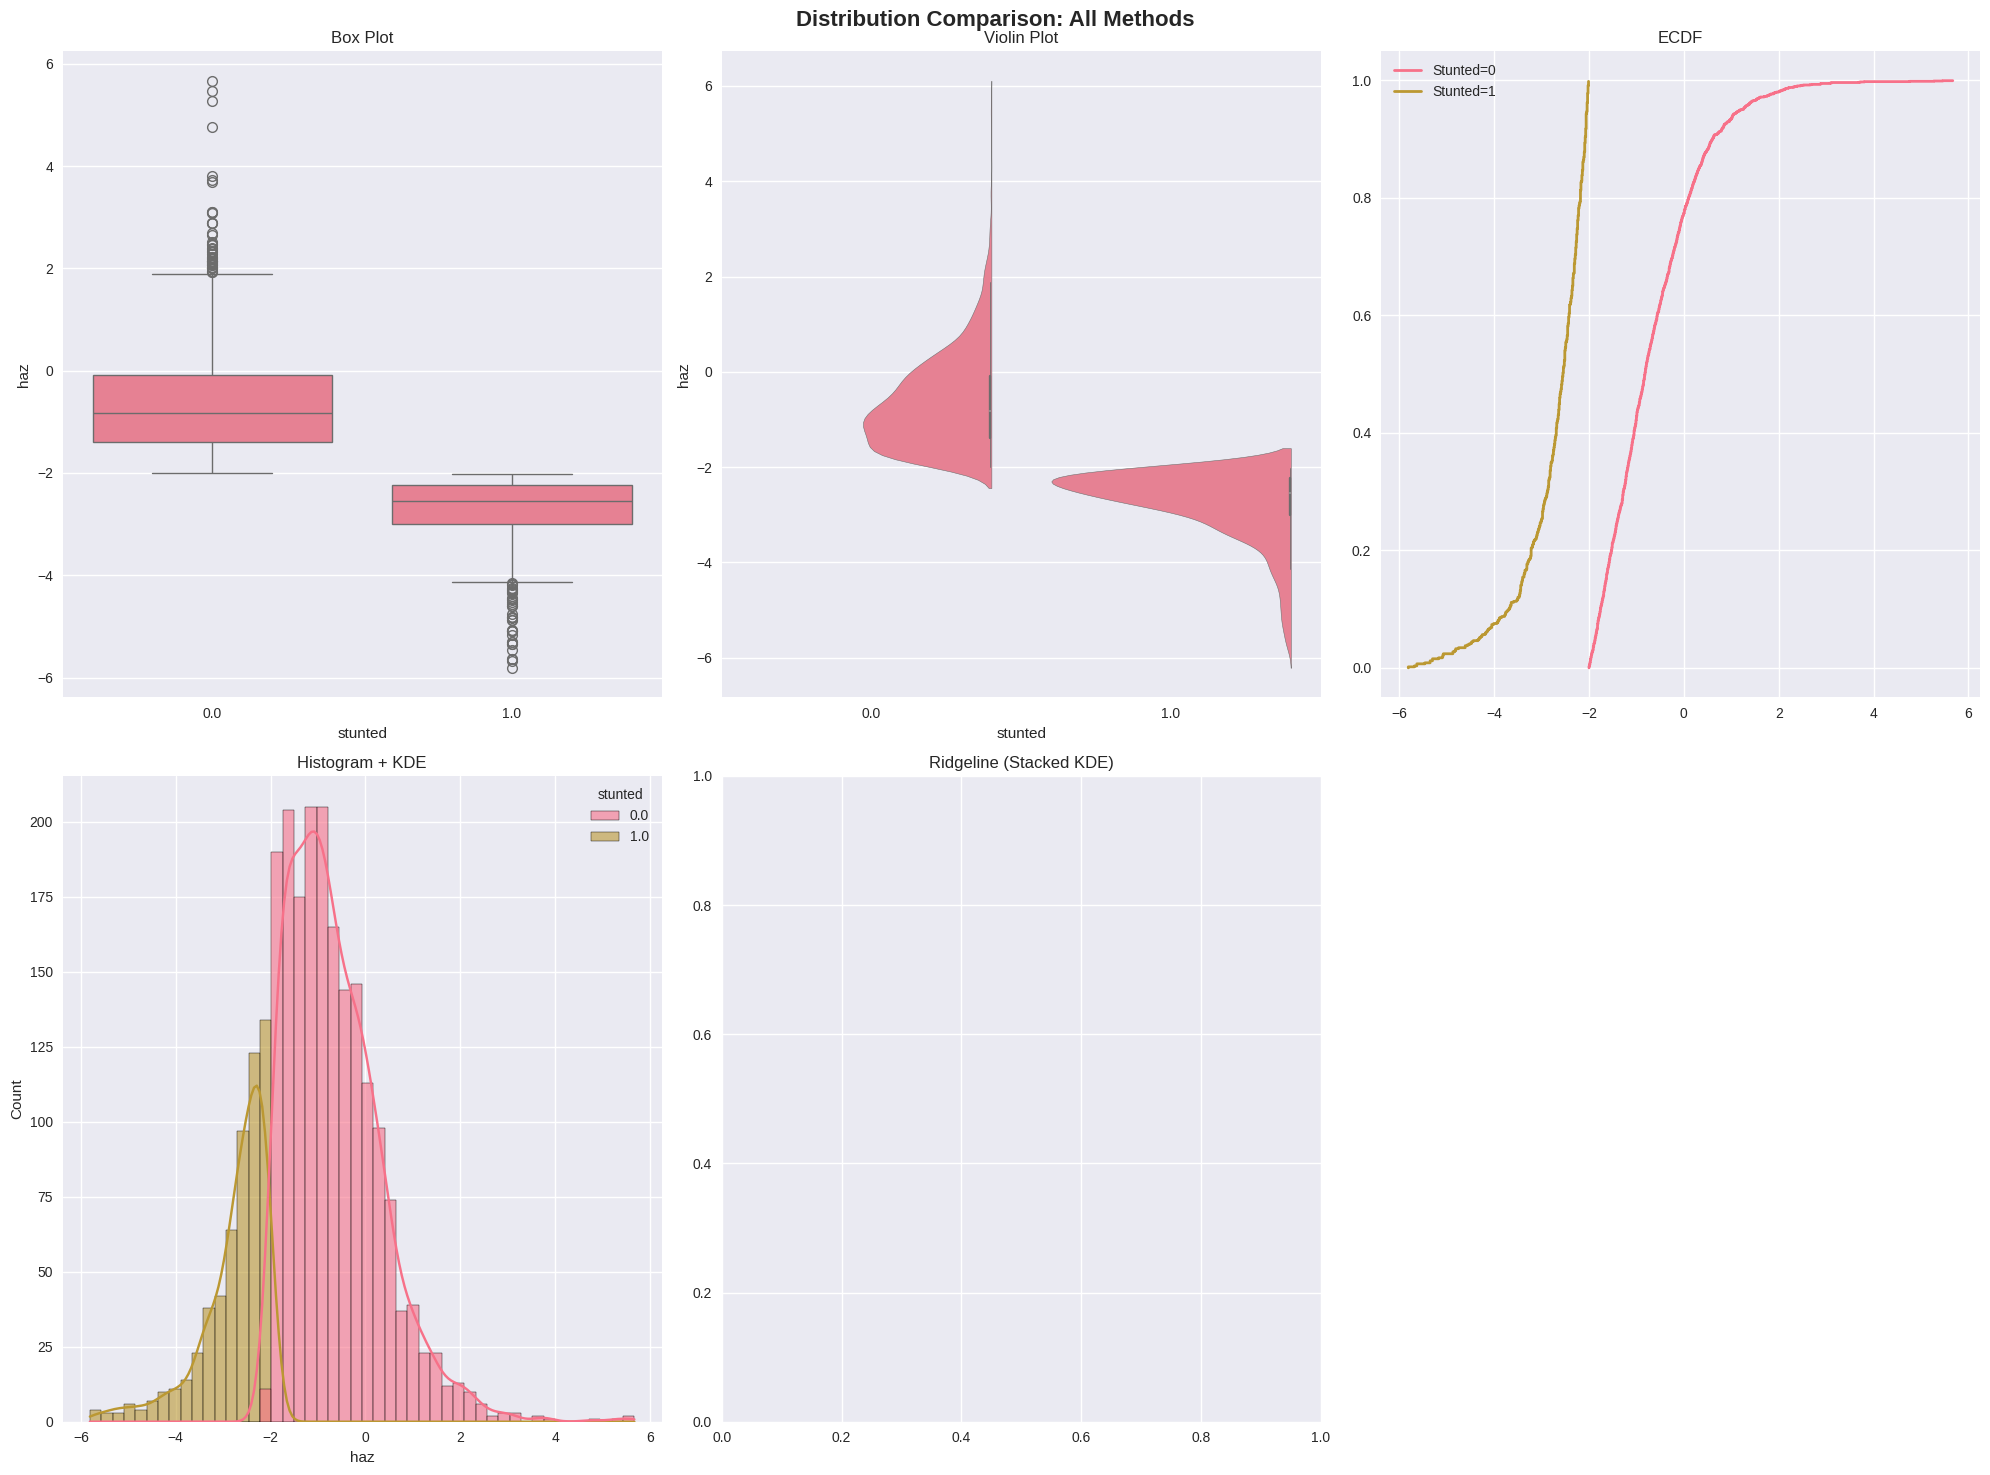

In [ ]:
fig = plt.figure(figsize=(20, 15))

# Box plot
ax1 = plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='stunted', y='haz', ax=ax1)
ax1.set_title('Box Plot')

# Violin plot
ax2 = plt.subplot(2, 3, 2)
sns.violinplot(data=df, x='stunted', y='haz', split=True, ax=ax2)
ax2.set_title('Violin Plot')

# ECDF
ax3 = plt.subplot(2, 3, 3)
for stunted in [0, 1]:
    subset = df[df['stunted'] == stunted]['haz'].dropna()
    p = np.arange(len(subset)) / len(subset)
    sorted_data = np.sort(subset)
    ax3.step(sorted_data, p, label=f'Stunted={stunted}', linewidth=2)
ax3.set_title('ECDF')
ax3.legend()

# Histograms
ax4 = plt.subplot(2, 3, 4)
sns.histplot(data=df, x='haz', hue='stunted', kde=True, ax=ax4, alpha=0.6)
ax4.set_title('Histogram + KDE')

# Ridgeline (simplified)
ax5 = plt.subplot(2, 3, 5)
for i, wealth in enumerate(['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']):
    subset = df[df['wealth_index_clean'] == wealth]['haz'].dropna()
    sns.kdeplot(subset, ax=ax5, label=wealth, alpha=0.7)
ax5.set_title('Ridgeline (Stacked KDE)')

plt.suptitle('Distribution Comparison: All Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

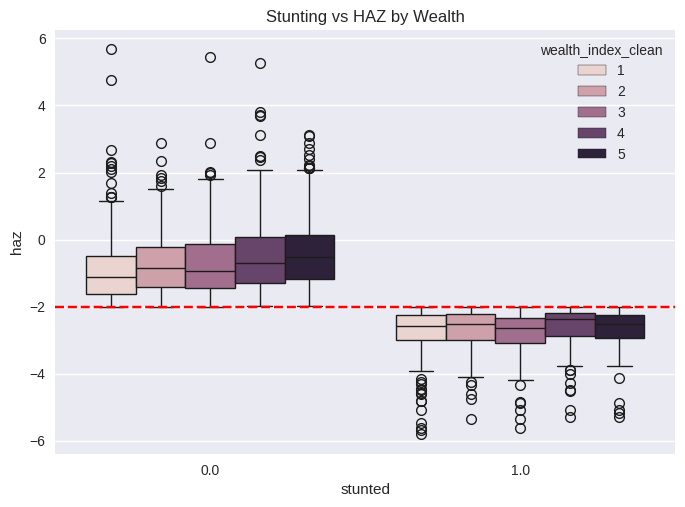

In [ ]:
# BEST for stunting analysis
sns.boxplot(data=df, x='stunted', y='haz', hue='wealth_index_clean')
plt.title('Stunting vs HAZ by Wealth')
plt.axhline(y=-2, color='red', linestyle='--')
plt.show()

In [ ]:
def iqr_outliers(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lb) | (df[col] > ub)]

        outlier_info[col] = {
            "lower_bound": lb,
            "upper_bound": ub,
            "num_outliers": outliers.shape[0]
        }

    return outlier_info


In [ ]:
columns_to_check = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

outlier_results = iqr_outliers(df, columns_to_check)


In [ ]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -21.5
Upper bound: 54.5
Number of outliers: 0

Column: children_ever_born
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 8

Column: mother_age
Lower bound: 9.0
Upper bound: 41.0
Number of outliers: 11

Column: birth_order
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 7

Column: mother_bmi
Lower bound: 113.47499999999997
Upper bound: 334.87500000000006
Number of outliers: 44


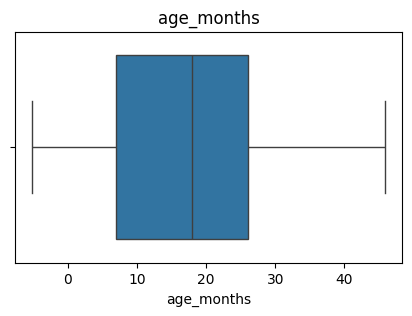

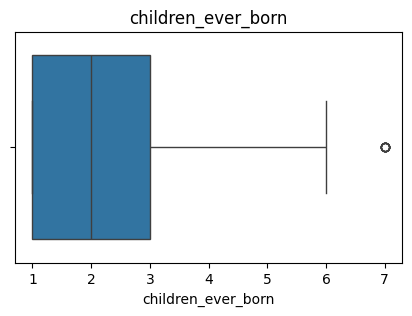

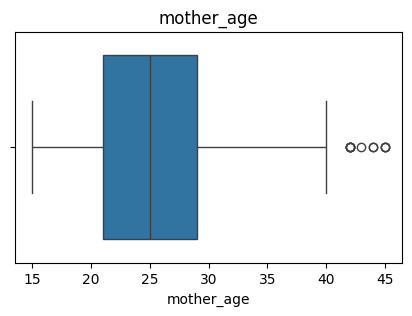

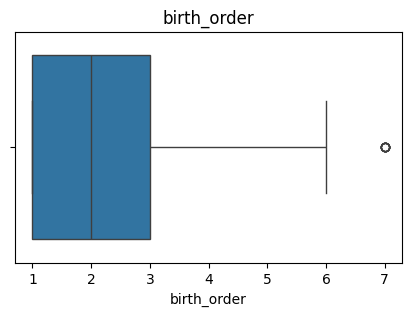

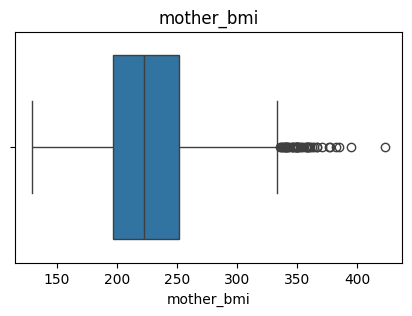

In [ ]:
for col in columns_to_check:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


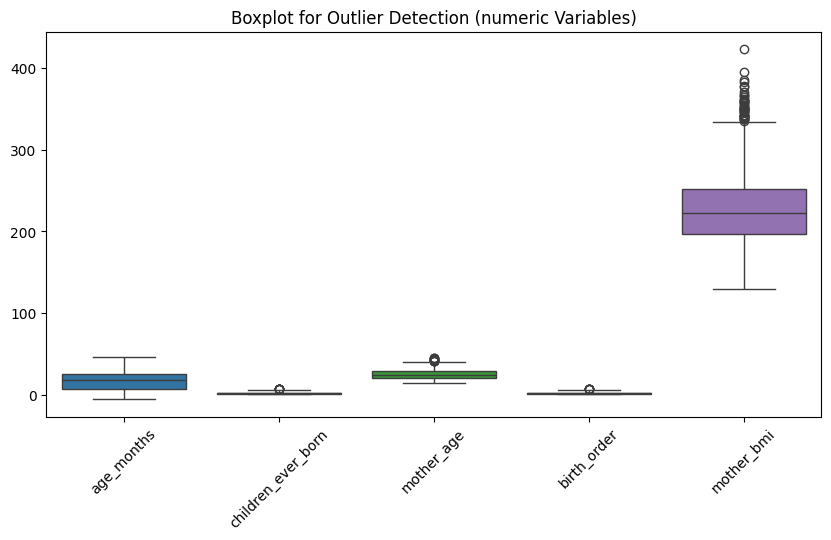

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection (numeric Variables)")
plt.show()



# whisker use to handle outlier

In [ ]:
import pandas as pd
import numpy as np

# 1. Define a helper to calculate bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
def get_winsorize_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

cols = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi']

for col in cols:
    # Calculate bounds
    lw, uw = get_winsorize_bounds(df[col])

    # Clip values between lw and uw
    df[col] = df[col].clip(lower=lw, upper=uw)

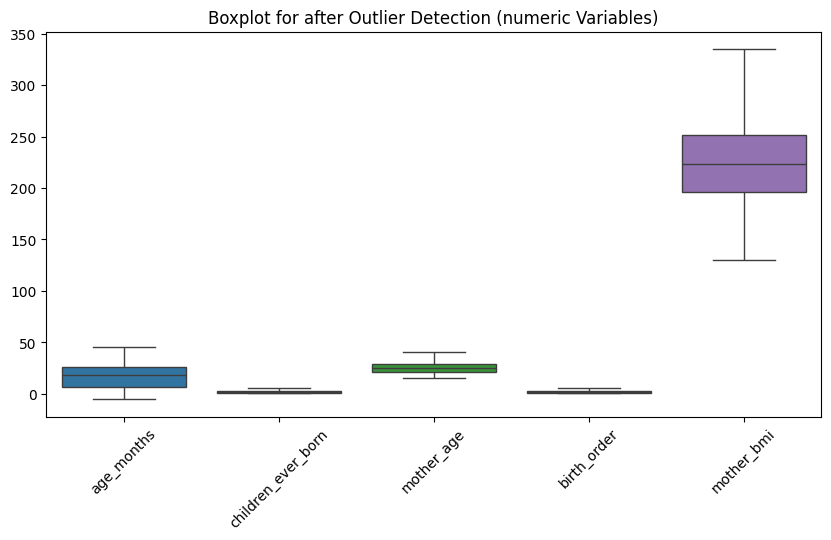

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for after Outlier Detection (numeric Variables)")
plt.show()

### Scaling numerical variables

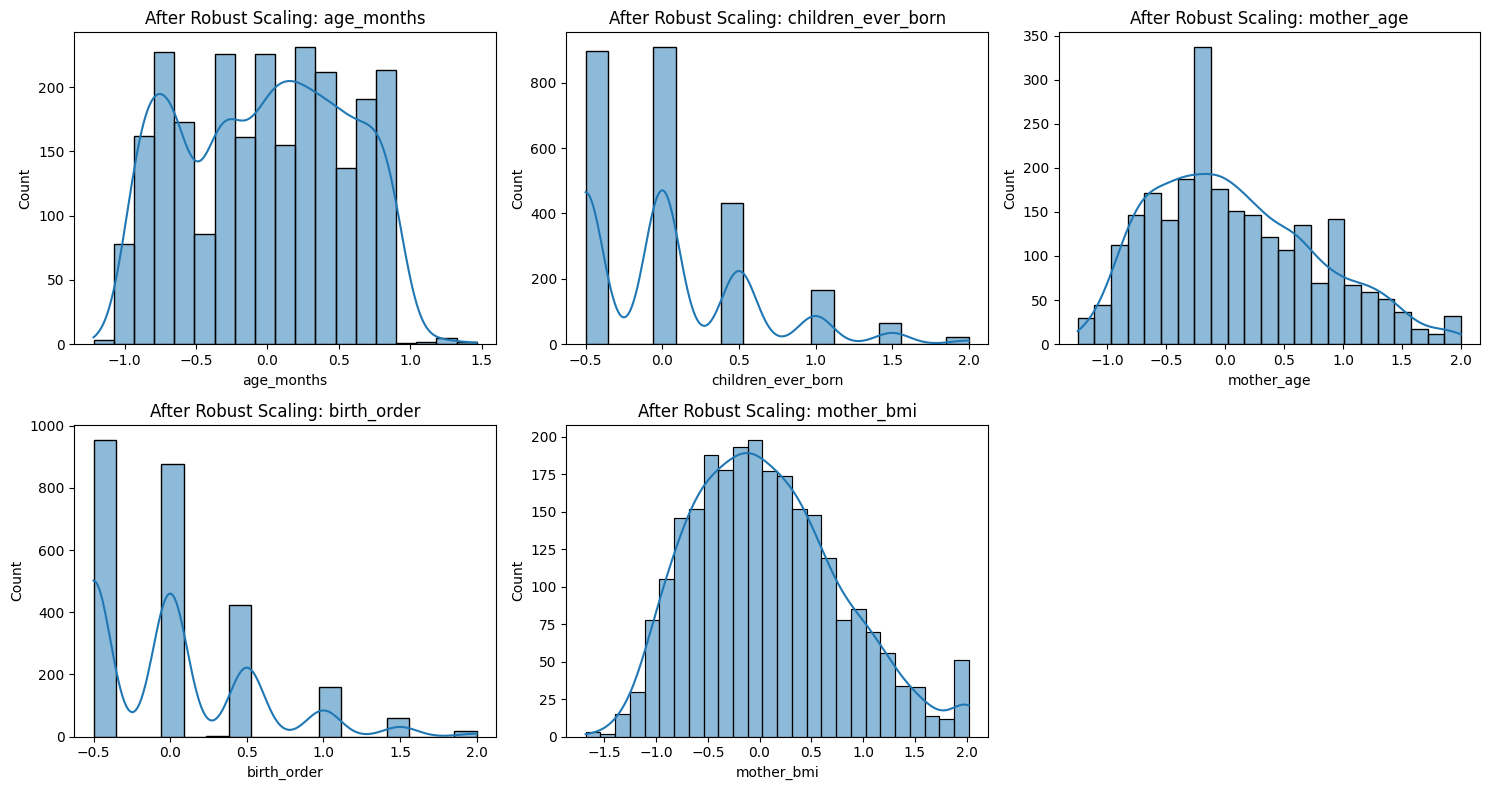

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Columns to scale
cols_to_scale = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi'
]

# Apply Robust Scaling
scaler = RobustScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=cols_to_scale,
    index=df.index
)

# Plot distributions after scaling
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"After Robust Scaling: {col}")

plt.tight_layout()
plt.show()


# class imbalance checking

In [ ]:
# Class counts
stunted_counts = df['stunted'].value_counts()

# Class percentages
stunted_percent = df['stunted'].value_counts(normalize=True) * 100

print("Class Counts:")
print(stunted_counts)

print("\nClass Percentages (%):")
print(stunted_percent.round(2))


Class Counts:
stunted
0    1908
1     583
Name: count, dtype: int64

Class Percentages (%):
stunted
0    76.6
1    23.4
Name: proportion, dtype: float64


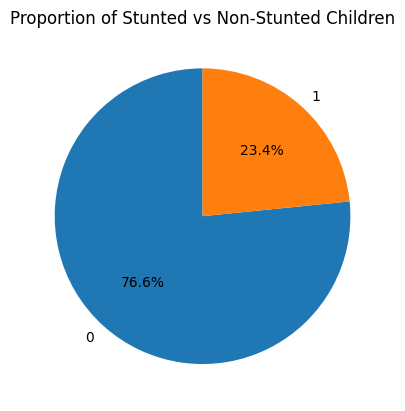

In [ ]:
df['stunted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Proportion of Stunted vs Non-Stunted Children')
plt.show()



# Train Test Split (80% train, 20% test)

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Target
y = df["stunted"].astype(int)

# Drop non-predictor columns
drop_cols = ["stunted", "haz", "sample_weight", "wt", "child_line"]
X = df.drop(columns=drop_cols, errors="ignore")

# Make data safe before split
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Save master split indices for later feature-selection blocks
train_idx = X_train.index
test_idx = X_test.index

# Sanity checks
print("Final feature count:", X.shape[1])
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verify removal
print("haz in X?", "haz" in X.columns)
print("weight in X?", any(col in X.columns for col in ["sample_weight", "wt"]))
print("child_line in X?", "child_line" in X.columns)

# Check saved indices
print("train_idx length:", len(train_idx))
print("test_idx length:", len(test_idx))

Final feature count: 19
Train shape: (1992, 19)
Test shape: (499, 19)
haz in X? False
weight in X? False
child_line in X? False
train_idx length: 1992
test_idx length: 499


Before SMOTE (Training Set Only):
stunted
0    1526
1     466
Name: count, dtype: int64

Percentage before SMOTE:
stunted
0    76.61
1    23.39
Name: proportion, dtype: float64

After SMOTE (Training Set Only):
stunted
0    1526
1    1526
Name: count, dtype: int64

Percentage after SMOTE:
stunted
0    50.0
1    50.0
Name: proportion, dtype: float64


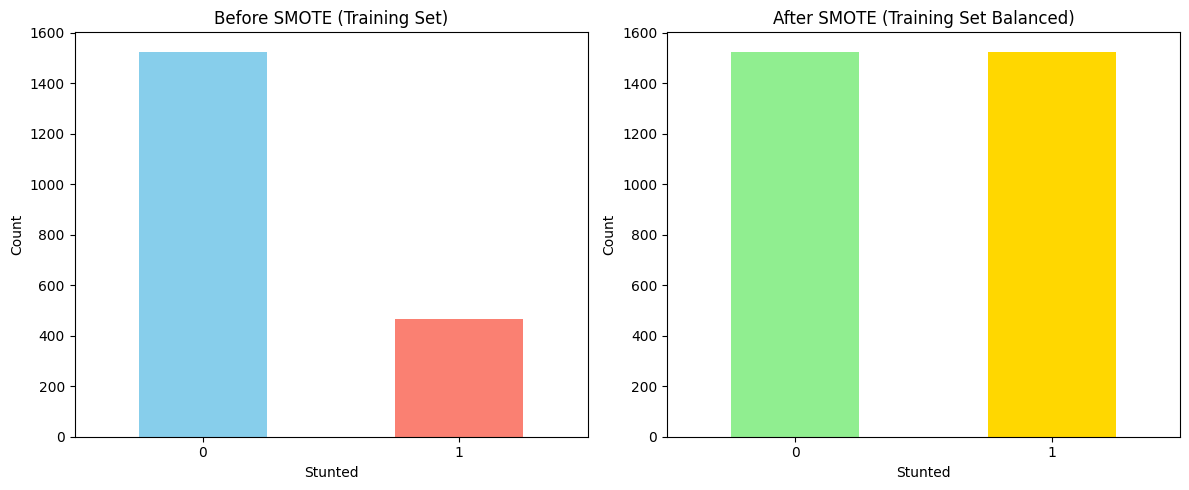


Shapes after SMOTE:
X_train shape: (3052, 19)
X_test shape : (499, 19)
y_train shape: (3052,)
y_test shape : (499,)


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Keep original column names so later code does not break
if isinstance(X_train, pd.DataFrame):
    train_columns = X_train.columns
    X_train_smote = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).copy()
else:
    X_train_smote = pd.DataFrame(np.nan_to_num(X_train))
    train_columns = X_train_smote.columns

# Keep X_test safe too, but DO NOT apply SMOTE on test set
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).copy()
else:
    X_test = pd.DataFrame(np.nan_to_num(X_test))

# Make sure targets are clean
y_train_smote = pd.Series(y_train).astype(int).reset_index(drop=True)
y_test = pd.Series(y_test).astype(int).reset_index(drop=True)

print("Before SMOTE (Training Set Only):")
print(y_train_smote.value_counts().sort_index())
print("\nPercentage before SMOTE:")
print((y_train_smote.value_counts(normalize=True).sort_index() * 100).round(2))

# ==============================================
# APPLY SMOTE ONLY ON TRAINING SET
# ==============================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smote, y_train_smote)

# Convert back to DataFrame/Series so later code continues to work
X_train = pd.DataFrame(X_train_resampled, columns=train_columns)
y_train = pd.Series(y_train_resampled, name='stunted')

print("\n" + "=" * 50)
print("After SMOTE (Training Set Only):")
print(y_train.value_counts().sort_index())
print("\nPercentage after SMOTE:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

# ==============================================
# VISUALIZATION
# ==============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
y_train_smote.value_counts().sort_index().plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    ax=axes[0]
)
axes[0].set_title('Before SMOTE (Training Set)')
axes[0].set_xlabel('Stunted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['0', '1'], rotation=0)

# After SMOTE
y_train.value_counts().sort_index().plot(
    kind='bar',
    color=['lightgreen', 'gold'],
    ax=axes[1]
)
axes[1].set_title('After SMOTE (Training Set Balanced)')
axes[1].set_xlabel('Stunted')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

# ==============================================
# FINAL SHAPE CHECK
# ==============================================
print("\nShapes after SMOTE:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# feature list

In [ ]:
for i, feat in enumerate(X.columns, start=1):
    print(f"{i}. {feat}")

1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_edu
7. division
8. mother_age
9. mother_bmi
10. father_occ_clean
11. skilled_birth
12. toilet_improved
13. delivery_place_3cat
14. has_tv_clean
15. has_electricity_clean
16. reads_newspaper_clean
17. small_at_birth
18. wants_more_children
19. wealth_index_clean


# 1. Filter Method: SelectKBest with Mutual Information

This selects top features based on mutual information (measures dependency between features and target).
It's fast and doesn't overfit, but ignores feature interactions.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Work on a copy of existing X
X_fe = X.copy()
y_fe = y.copy()

# Handle missing values
X_fe = X_fe.fillna(X_fe.median(numeric_only=True))

for col in X_fe.select_dtypes(include=['object', 'category']).columns:
    X_fe[col] = X_fe[col].fillna(X_fe[col].mode()[0])

# Encode categorical variables
X_fe = pd.get_dummies(X_fe, drop_first=True)

# Use master split indices from main split cell
X_train = X_fe.loc[train_idx].copy()
X_test = X_fe.loc[test_idx].copy()
y_train = y_fe.loc[train_idx].copy()
y_test = y_fe.loc[test_idx].copy()

# Ensure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Final NaN safety
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert back to DataFrame so column names stay available
X_train = pd.DataFrame(X_train, columns=X_fe.columns)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Initialize and fit selector
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected features
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Selected features:
1. age_months
2. mother_edu
3. birth_order
4. children_ever_born
5. father_edu
6. mother_age
7. father_occ_clean
8. skilled_birth
9. delivery_place_3cat
10. wealth_index_clean


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
import pandas as pd

# Use existing X and y
X_fs = X.copy()
y_fs = y.copy()

# Use master split indices from main split cell
X_train = X_fs.loc[train_idx].copy()
X_test = X_fs.loc[test_idx].copy()
y_train = y_fs.loc[train_idx].copy()
y_test = y_fs.loc[test_idx].copy()

# Ensure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Final NaN safety
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert back to DataFrame so column names stay available
X_train = pd.DataFrame(X_train, columns=X_fs.columns)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Initialize filter selector
selector = SelectKBest(score_func=mutual_info_classif, k=15)

# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

# Now use X_train_selected and X_test_selected for modeling

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Selected features:
1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_edu
7. division
8. mother_age
9. mother_bmi
10. father_occ_clean
11. skilled_birth
12. toilet_improved
13. delivery_place_3cat
14. has_tv_clean
15. wealth_index_clean


# 2. Wrapper Method: Recursive Feature Elimination (RFE) with LogisticRegression
This recursively removes least important features using a model (here, LogisticRegression for multiclass). More accurate but slower.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import pandas as pd

# Use existing X and y
X_rfe = X.copy()
y_rfe = y.copy()

# Use master split indices saved from the main split cell
X_train = X_rfe.loc[train_idx].copy()
X_test = X_rfe.loc[test_idx].copy()
y_train = y_rfe.loc[train_idx].copy()
y_test = y_rfe.loc[test_idx].copy()

# Ensure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Initialize wrapper selector
estimator = LogisticRegression(random_state=42, max_iter=1000)
selector = RFE(estimator, n_features_to_select=15)

# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.support_]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Selected features:
1. mother_edu
2. birth_order
3. mother_occ
4. children_ever_born
5. father_edu
6. father_occ_clean
7. skilled_birth
8. toilet_improved
9. delivery_place_3cat
10. has_tv_clean
11. has_electricity_clean
12. reads_newspaper_clean
13. small_at_birth
14. wants_more_children
15. wealth_index_clean


# 3.Stepwise Backward Feature Selection Code

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import pandas as pd

# Use existing X and y
X_rfe = X.copy()
y_rfe = y.copy()

# Use master split indices saved from the main split cell
X_train = X_rfe.loc[train_idx].copy()
X_test = X_rfe.loc[test_idx].copy()
y_train = y_rfe.loc[train_idx].copy()
y_test = y_rfe.loc[test_idx].copy()

# Ensure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Initialize backward selector (RFE with LogisticRegression; select top 15 features)
estimator = LogisticRegression(random_state=42, max_iter=1000)
selector = RFE(estimator, n_features_to_select=15, step=1)

# Fit on training data
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.support_]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

# Transform data to selected features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Now use X_train_selected and X_test_selected for modeling

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Selected features:
1. mother_edu
2. birth_order
3. mother_occ
4. children_ever_born
5. father_edu
6. father_occ_clean
7. skilled_birth
8. toilet_improved
9. delivery_place_3cat
10. has_tv_clean
11. has_electricity_clean
12. reads_newspaper_clean
13. small_at_birth
14. wants_more_children
15. wealth_index_clean


# 4.Boruta Algorithm

In [ ]:
!pip install boruta


In [ ]:
from boruta import BorutaPy


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Use existing split data directly
x_train_boruta = X_train.copy()
x_test_boruta = X_test.copy()

# Convert to numpy arrays (Boruta requirement)
x_train_np = x_train_boruta.values
y_train_np = y_train.values if hasattr(y_train, "values") else y_train


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=45,
    n_jobs=-1,
    class_weight='balanced'
)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from imblearn.over_sampling import SMOTE

# Use existing saved X and y
X_boruta = X.copy()
y_boruta = y.copy()

# Check X_boruta for issues before split alignment
print("Data types in X_boruta:")
print(X_boruta.dtypes)
print("Any NaNs in X_boruta?", X_boruta.isnull().sum().sum() > 0)
print("Any non-numerical in X_boruta?", X_boruta.select_dtypes(include=[object]).shape[1] > 0)

# Use master split indices saved from the main split cell
X_train = X_boruta.loc[train_idx].copy()
X_test = X_boruta.loc[test_idx].copy()
y_train = y_boruta.loc[train_idx].copy()
y_test = y_boruta.loc[test_idx].copy()

# Make safe numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Convert to numpy
try:
    X_train_np = np.array(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_np = np.array(y_train.values if hasattr(y_train, 'values') else y_train)
except Exception as e:
    print(f"Conversion error: {e}")
    raise

# Validate shapes and types
print("X_train_np shape:", X_train_np.shape, "Type:", type(X_train_np))
print("y_train_np shape:", y_train_np.shape, "Type:", type(y_train_np))

if X_train_np.ndim != 2:
    raise ValueError("X_train_np must be 2D. Reshape if needed.")
if y_train_np.ndim != 1:
    raise ValueError("y_train_np must be 1D.")

# Initialize RF (Boruta requires a tree-based estimator)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Boruta
boruta = BorutaPy(estimator=rf, n_estimators='auto', verbose=2, random_state=45)

# Fit
try:
    boruta.fit(X_train_np, y_train_np)
    selected_features = X_train.columns[boruta.support_].tolist()
    print("Selected features:", selected_features)
except ValueError as e:
    print(f"Boruta fit error: {e}")
    print("Likely cause: Check X_boruta preprocessing or shapes above.")

Data types in X_boruta:
age_months               float64
mother_edu                 int64
birth_order              float64
mother_occ                 int64
children_ever_born       float64
father_edu                 int64
division                   int64
mother_age               float64
mother_bmi               float64
father_occ_clean           int64
skilled_birth              int64
toilet_improved            int64
delivery_place_3cat        int64
has_tv_clean               int64
has_electricity_clean      int64
reads_newspaper_clean      int64
small_at_birth             int64
wants_more_children        int64
wealth_index_clean         int64
dtype: object
Any NaNs in X_boruta? False
Any non-numerical in X_boruta? False
After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
X_train_np shape: (3052, 19) Type: <class 'numpy.ndarray'>
y_train_np shape: (3052,) Type: <class 'numpy.ndarray'>
Iteration: 	1 / 100
Confirmed: 	0
Tentat

# 5.Grey Wolf Optimizer (GWO)  Feature Selection

Works well for complex datasets,
 Handles non-linear relationships,
 Avoids local minima,
 Good balance between exploration & exploitation,

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

# Use existing X and y
X_gwo = X.copy()
y_gwo = y.copy()

n_features = X_gwo.shape[1]

# Use master split indices saved from the main split cell
X_train = X_gwo.loc[train_idx].copy()
X_test = X_gwo.loc[test_idx].copy()
y_train = y_gwo.loc[train_idx].copy()
y_test = y_gwo.loc[test_idx].copy()

# Make safe numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Convert to numpy (for slicing)
X_train_np = X_train.values
X_test_np = X_test.values

# GWO Parameters
n_wolves = 10
max_iter = 20
a_max = 2
a_min = 0

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]

        model = CatBoostClassifier(iterations=50, verbose=0, random_state=42)
        model.fit(selected_train, y_train)

        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)

    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population
population = np.random.randint(0, 2, (n_wolves, n_features))

# Initialize best wolves
alpha_pos = np.copy(population[0])
beta_pos = np.copy(population[1])
delta_pos = np.copy(population[2])
alpha_score = 0
beta_score = 0
delta_score = 0

# GWO Loop
for iter in range(max_iter):
    a = a_max - (a_max - a_min) * (iter / max_iter)

    for i in range(n_wolves):
        fitness = fitness_function(population[i], X_train_np, X_test_np, y_train, y_test)

        if fitness > alpha_score:
            alpha_score = fitness
            alpha_pos = np.copy(population[i])
        elif fitness > beta_score:
            beta_score = fitness
            beta_pos = np.copy(population[i])
        elif fitness > delta_score:
            delta_score = fitness
            delta_pos = np.copy(population[i])

    for i in range(n_wolves):
        for j in range(n_features):
            r1, r2 = np.random.rand(), np.random.rand()
            A1 = 2 * a * r1 - a
            C1 = 2 * r2
            D_alpha = abs(C1 * alpha_pos[j] - population[i][j])
            X1 = alpha_pos[j] - A1 * D_alpha

            r1, r2 = np.random.rand(), np.random.rand()
            A2 = 2 * a * r1 - a
            C2 = 2 * r2
            D_beta = abs(C2 * beta_pos[j] - population[i][j])
            X2 = beta_pos[j] - A2 * D_beta

            r1, r2 = np.random.rand(), np.random.rand()
            A3 = 2 * a * r1 - a
            C3 = 2 * r2
            D_delta = abs(C3 * delta_pos[j] - population[i][j])
            X3 = delta_pos[j] - A3 * D_delta

            new_pos = (X1 + X2 + X3) / 3
            population[i][j] = 1 if 1 / (1 + np.exp(-10 * (new_pos - 0.5))) > 0.5 else 0

    print(f"Iter {iter+1}: Best Score = {alpha_score:.4f}")

# Results
selected_indices = np.where(alpha_pos == 1)[0]
selected_features = X_gwo.columns[selected_indices].tolist()

print("Selected features:", selected_features)
print("Best accuracy:", alpha_score)

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Iter 1: Best Score = 0.7335
Iter 2: Best Score = 0.7395
Iter 3: Best Score = 0.7395
Iter 4: Best Score = 0.7395
Iter 5: Best Score = 0.7475
Iter 6: Best Score = 0.7475
Iter 7: Best Score = 0.7475
Iter 8: Best Score = 0.7475
Iter 9: Best Score = 0.7475
Iter 10: Best Score = 0.7475
Iter 11: Best Score = 0.7475
Iter 12: Best Score = 0.7475
Iter 13: Best Score = 0.7475
Iter 14: Best Score = 0.7475
Iter 15: Best Score = 0.7475
Iter 16: Best Score = 0.7475
Iter 17: Best Score = 0.7475
Iter 18: Best Score = 0.7475
Iter 19: Best Score = 0.7475
Iter 20: Best Score = 0.7475
Selected features: ['age_months', 'birth_order', 'mother_occ', 'father_edu', 'division', 'mother_age', 'delivery_place_3cat', 'has_electricity_clean', 'reads_newspaper_clean', 'wants_more_children', 'wealth_index_clean']
Best accuracy: 0.7474949899799599


# snake optimization

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Use existing saved X and y
X_so = X.copy()
y_so = y.copy()
n_features = X_so.shape[1]

# Use master split indices saved from the main split cell
X_train = X_so.loc[train_idx].copy()
X_test = X_so.loc[test_idx].copy()
y_train = y_so.loc[train_idx].copy()
y_test = y_so.loc[test_idx].copy()

# Make safe numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Convert to numpy for subset slicing
X_train_np = X_train.values
X_test_np = X_test.values

# SO Parameters
n_snakes = 20
max_iter = 50
c1 = 1
c2 = 0.5

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(selected_train, y_train)
        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)
    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population (binary)
population = np.random.randint(0, 2, (n_snakes, n_features))

# Initialize best snake
best_snake = np.copy(population[0])
best_fitness = 0

# SO Main Loop
for iter in range(max_iter):
    fitness_values = np.array([
        fitness_function(population[i], X_train_np, X_test_np, y_train, y_test)
        for i in range(n_snakes)
    ])

    # Update best
    max_idx = np.argmax(fitness_values)
    if fitness_values[max_idx] > best_fitness:
        best_fitness = fitness_values[max_idx]
        best_snake = np.copy(population[max_idx])

    # Update population
    for i in range(n_snakes):
        for j in range(n_features):
            r1 = np.random.rand()
            r2 = np.random.rand()
            if r1 < c1:
                population[i][j] = best_snake[j]
            elif r2 < c2:
                population[i][j] = np.random.randint(0, 2)

    print(f"Iter {iter+1}: Best Fitness = {best_fitness:.4f}")

# Results
selected_indices = np.where(best_snake == 1)[0]
selected_features = X_so.columns[selected_indices].tolist()
print("Selected features:", selected_features)
print("Best accuracy:", best_fitness)

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Iter 1: Best Fitness = 0.6733
Iter 2: Best Fitness = 0.6733
Iter 3: Best Fitness = 0.6733
Iter 4: Best Fitness = 0.6733
Iter 5: Best Fitness = 0.6733
Iter 6: Best Fitness = 0.6733
Iter 7: Best Fitness = 0.6733
Iter 8: Best Fitness = 0.6733
Iter 9: Best Fitness = 0.6733
Iter 10: Best Fitness = 0.6733
Iter 11: Best Fitness = 0.6733
Iter 12: Best Fitness = 0.6733
Iter 13: Best Fitness = 0.6733
Iter 14: Best Fitness = 0.6733
Iter 15: Best Fitness = 0.6733
Iter 16: Best Fitness = 0.6733
Iter 17: Best Fitness = 0.6733
Iter 18: Best Fitness = 0.6733
Iter 19: Best Fitness = 0.6733
Iter 20: Best Fitness = 0.6733
Iter 21: Best Fitness = 0.6733
Iter 22: Best Fitness = 0.6733
Iter 23: Best Fitness = 0.6733
Iter 24: Best Fitness = 0.6733
Iter 25: Best Fitness = 0.6733
Iter 26: Best Fitness = 0.6733
Iter 27: Best Fitness = 0.6733
Iter 28: Best Fitness = 0.6733
Iter 29: Best Fitness = 0.

In [ ]:
import pandas as pd
import numpy as np

# Use existing saved X and y (no split, no SMOTE here)
X_fixed = X.copy()
y_fixed = y.copy()


X_fixed = X_fixed.apply(pd.to_numeric, errors='coerce').fillna(0)
y_fixed = y_fixed.astype(int)

feature_names = X_fixed.columns

# Result of feature selection methods

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from imblearn.over_sampling import SMOTE

# -----------------------------
# Use master split
# -----------------------------
X_all = X.copy()
y_all = y.copy()

X_train = X_all.loc[train_idx].copy()
X_test = X_all.loc[test_idx].copy()
y_train = y_all.loc[train_idx].copy()
y_test = y_all.loc[test_idx].copy()

# Make safe numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Save original feature names before SMOTE
feature_names = X_train.columns

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert back safely
X_train = pd.DataFrame(X_train, columns=feature_names)
y_train = pd.Series(y_train, name='stunted')

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# -----------------------------
# 1 Mutual Information
# -----------------------------
mi = SelectKBest(mutual_info_classif, k='all')
mi.fit(X_train, y_train)

mi_rank = pd.Series(mi.scores_, index=feature_names).rank(ascending=False)

# -----------------------------
# 2 Random Forest Importance
# -----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_rank = pd.Series(rf.feature_importances_, index=feature_names).rank(ascending=False)

# -----------------------------
# 3 RFE
# -----------------------------
lr = LogisticRegression(max_iter=1000)

rfe = RFE(lr, n_features_to_select=15)
rfe.fit(X_train, y_train)

rfe_rank = pd.Series(rfe.ranking_, index=feature_names)

# -----------------------------
# 4 LASSO
# -----------------------------
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

lasso_rank = pd.Series(np.abs(lasso.coef_), index=feature_names).rank(ascending=False)

# -----------------------------
# 5 Boruta
# -----------------------------
rf_boruta = RandomForestClassifier(n_estimators=200, random_state=42)

boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42)

boruta.fit(X_train.to_numpy(), y_train.to_numpy())

boruta_rank = pd.Series(np.where(boruta.support_, 1, 2), index=feature_names)

# -----------------------------
# 6 Snake Optimization Feature Selection
# -----------------------------
from sklearn.metrics import accuracy_score

X_np = X_train.to_numpy()
y_np = y_train.to_numpy()

n_features = X_np.shape[1]

# parameters
n_snakes = 20
max_iter = 30

# initialize population
population = np.random.randint(0, 2, (n_snakes, n_features))

best_snake = population[0]
best_score = 0

def fitness_function(mask):
    if np.sum(mask) == 0:
        return 0

    X_selected = X_np[:, mask == 1]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_selected, y_np)

    score = model.score(X_selected, y_np)
    return score

for i in range(max_iter):

    scores = []

    for snake in population:
        score = fitness_function(snake)
        scores.append(score)

    scores = np.array(scores)

    best_idx = np.argmax(scores)

    if scores[best_idx] > best_score:
        best_score = scores[best_idx]
        best_snake = population[best_idx]

    # update population
    for j in range(n_snakes):
        rand = np.random.rand(n_features)
        population[j] = np.where(rand < 0.5, best_snake, population[j])

# Convert to ranking
snake_rank = pd.Series(best_snake, index=feature_names).rank(ascending=False)

# -----------------------------
# Combine All Rankings
# -----------------------------
rank_df = pd.DataFrame({
    'MI_Rank': mi_rank,
    'RF_Rank': rf_rank,
    'RFE_Rank': rfe_rank,
    'LASSO_Rank': lasso_rank,
    'Boruta_Rank': boruta_rank,
    'Snake_Rank': snake_rank,
})

# -----------------------------
# Average Rank
# -----------------------------
rank_df['Average_Rank'] = rank_df.mean(axis=1)

rank_df = rank_df.sort_values('Average_Rank')

print(rank_df)

# -----------------------------
# Top Features
# -----------------------------
top_features = rank_df.head(15)

print("\nTop 15 Features:")
print(top_features)

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
                       MI_Rank  RF_Rank  RFE_Rank  LASSO_Rank  Boruta_Rank  \
age_months                 2.0      1.0         3        12.0            1   
delivery_place_3cat        6.0      5.0         1         6.0            2   
mother_edu                11.0     10.0         1         2.0            2   
father_edu                 7.0      9.0         1         8.0            2   
toilet_improved           13.0     12.0         1         1.0            2   
father_occ_clean           5.0     11.0         1        11.0            2   
has_tv_clean              10.0     14.0         1         4.0            2   
birth_order                4.0      7.0         1        17.0            2   
mother_age                 1.0      3.0         4        13.0            1   
mother_bmi                12.0      2.0         5        14.0            1   
mother_occ                1

In [ ]:
top_features = rank_df.head(15)

In [ ]:
selected_features = top_features.index

In [ ]:
# CREATE NEW DATASET WITH SELECTED FEATURES
X_selected = X[selected_features]
print(f"\n📈 Original features: {X.shape[1]} → Selected features: {X_selected.shape[1]}")
print(f"Feature reduction: {100*(1 - X_selected.shape[1]/X.shape[1]):.1f}%")


📈 Original features: 19 → Selected features: 15
Feature reduction: 21.1%


In [ ]:
# Now use X_selected and selected_features in your models!
print(f"\n🎯 Ready to use: X_selected and selected_features")
print("X_selected.shape =", X_selected.shape)


🎯 Ready to use: X_selected and selected_features
X_selected.shape = (2491, 15)


In [ ]:
print("\nColumns in X_selected:")
for col in X_selected.columns:
    print(col)


Columns in X_selected:
age_months
delivery_place_3cat
mother_edu
father_edu
toilet_improved
father_occ_clean
has_tv_clean
birth_order
mother_age
mother_bmi
mother_occ
children_ever_born
wealth_index_clean
skilled_birth
wants_more_children


In [ ]:
# 1️⃣ Import libraries
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2️⃣ Define individual models with fixed random_state
logreg = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(probability=True, random_state=42)  # probability=True needed for soft voting
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

# 3️⃣ Create a voting ensemble (soft voting for probabilities)
ensemble_model = VotingClassifier(
    estimators=[
        ('LogReg', logreg),
        ('SVM', svm),
        ('AdaBoost', ada),
        ('GB', gb),
        ('DT', dt),
        ('KNN', knn),
        ('NB', nb)
    ],
    voting='soft'  # soft voting averages predicted probabilities
)

# 4️⃣ Train ensemble on your selected features
ensemble_model.fit(X_train_selected, y_train)

# 5️⃣ Make predictions
y_pred = ensemble_model.predict(X_test_selected)

# 6️⃣ Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Ensemble Accuracy: 0.657314629258517

Confusion Matrix:
 [[287  95]
 [ 76  41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       382
           1       0.30      0.35      0.32       117

    accuracy                           0.66       499
   macro avg       0.55      0.55      0.55       499
weighted avg       0.68      0.66      0.67       499



# Now heading to model fit step.

In [ ]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)
import numpy as np
import pandas as pd

# Scale for ALL models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== 7 MODELS ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# ========== TRAIN & EVALUATE ALL 7 ==========
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING: {name}")
    print(f"{'='*50}")

    try:
        # Use scaled data for ALL models
        X_fit, X_pred = X_train_scaled, X_test_scaled

        model.fit(X_fit, y_train)
        y_pred = model.predict(X_pred)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_pred)[:, 1]
        else:
            y_prob = model.decision_function(X_pred)

        train_acc = accuracy_score(y_train, model.predict(X_fit)) * 100
        test_acc = accuracy_score(y_test, y_pred) * 100

        print("Train Accuracy (%):", round(train_acc, 2))
        print("Test Accuracy (%):", round(test_acc, 2))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("TN {}".format(cm[0, 0]))
        print("FP {}".format(cm[0, 1]))
        print("FN {}".format(cm[1, 0]))
        print("TP {}".format(cm[1, 1]))

        print("Accuracy rate {:.2f}".format((cm[0, 0] + cm[1, 1]) / np.sum(cm) * 100))
        print("Misclassification rate {:.2f}".format((cm[0, 1] + cm[1, 0]) / np.sum(cm) * 100))

        # Metrics
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall:", recall_score(y_test, y_pred))
        print("F1-score:", f1_score(y_test, y_pred))
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

        # Store results
        results.append({
            'Model': name,
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'F1': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_prob),
            'Overfit_Gap': (train_acc - test_acc) / 100
        })

        print("-" * 50)

    except Exception as e:
        print(f"❌ ERROR in {name}: {str(e)}")
        results.append({'Model': name, 'Error': str(e)})

# ========== SUMMARY TABLE ==========
results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False)
print("\n🏆 FINAL RANKING (Test Accuracy):")
print("=" * 60)
print(results_df.round(3).to_string(index=False))


TRAINING: Logistic Regression
Train Accuracy (%): 71.92
Test Accuracy (%): 64.73
TN 276
FP 106
FN 70
TP 47
Accuracy rate 64.73
Misclassification rate 35.27
Precision: 0.30718954248366015
Recall: 0.4017094017094017
F1-score: 0.34814814814814815
ROC-AUC: 0.6330827404125833
--------------------------------------------------

TRAINING: K-Nearest Neighbors
Train Accuracy (%): 83.36
Test Accuracy (%): 61.92
TN 261
FP 121
FN 69
TP 48
Accuracy rate 61.92
Misclassification rate 38.08
Precision: 0.28402366863905326
Recall: 0.41025641025641024
F1-score: 0.3356643356643357
ROC-AUC: 0.6000357989886785
--------------------------------------------------

TRAINING: Decision Tree
Train Accuracy (%): 74.31
Test Accuracy (%): 68.94
TN 299
FP 83
FN 72
TP 45
Accuracy rate 68.94
Misclassification rate 31.06
Precision: 0.3515625
Recall: 0.38461538461538464
F1-score: 0.3673469387755102
ROC-AUC: 0.6267284199221372
--------------------------------------------------

TRAINING: Gradient Boosting
Train Accuracy (

# KNN

In [ ]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
print("Train Accuracy (%):", knn.score(X_train, y_train) * 100)
print("Test Accuracy (%):", knn.score(X_test, y_test) * 100)

Train Accuracy (%): 83.25688073394495
Test Accuracy (%): 60.120240480961925


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation on training set
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

KNN Accuracy: 0.6012

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.62      0.70       382
           1       0.30      0.54      0.39       117

    accuracy                           0.60       499
   macro avg       0.56      0.58      0.55       499
weighted avg       0.69      0.60      0.63       499

CV Scores: [0.69394435 0.71031097 0.7704918  0.73278689 0.76557377]
Mean CV Accuracy: 0.7346 (+/- 0.0600)


In [ ]:
# ========== Import Libraries ==========
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Scale ALL DATA ==========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== Define Models ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON - ALL SCALED")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # ✅ ALL models use scaled data
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train) * 100
    test_acc = model.score(X_test_scaled, y_test) * 100
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON - ALL SCALED

Training Logistic Regression...
  ✓ Train Accuracy: 71.92%
  ✓ Test Accuracy:  64.73%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 83.36%
  ✓ Test Accuracy:  61.92%

Training Decision Tree...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  65.73%

Training Gradient Boosting...
  ✓ Train Accuracy: 85.26%
  ✓ Test Accuracy:  73.15%

Training AdaBoost...
  ✓ Train Accuracy: 78.44%
  ✓ Test Accuracy:  68.94%

Training SVM...
  ✓ Train Accuracy: 80.93%
  ✓ Test Accuracy:  69.94%

Training Naive Bayes...
  ✓ Train Accuracy: 71.26%
  ✓ Test Accuracy:  62.93%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
  Gradient Boosting               85.26              73.15
                SVM               80.93              69.94
           AdaBoost               78.44              68.94
      Decision Tree              100.00              65.73
Logistic Regression               71.92              64.73
        Naive Bayes               

🎓 LEARNING CURVES FOR ALL MODELS
Computing learning curve for Decision Tree...

Decision Tree: Final Train-Val Gap = 6.41%
⚡ WARNING: Mild Overfitting
Decision Tree        | Train Acc: 0.806 | Val Acc: 0.741 | Test Acc: 0.743
Computing learning curve for AdaBoost...

AdaBoost: Final Train-Val Gap = 0.91%
✅ Good: No significant overfitting
AdaBoost             | Train Acc: 0.772 | Val Acc: 0.763 | Test Acc: 0.774
Computing learning curve for Gradient Boosting...

Gradient Boosting: Final Train-Val Gap = 6.49%
⚡ WARNING: Mild Overfitting
Gradient Boosting    | Train Acc: 0.823 | Val Acc: 0.758 | Test Acc: 0.754
Computing learning curve for Logistic Regression...

Logistic Regression: Final Train-Val Gap = 0.14%
✅ Good: No significant overfitting
Logistic Regression  | Train Acc: 0.774 | Val Acc: 0.772 | Test Acc: 0.772
Computing learning curve for SVM...

SVM: Final Train-Val Gap = 2.04%
✅ Good: No significant overfitting
SVM                  | Train Acc: 0.785 | Val Acc: 0.765 | Test Ac

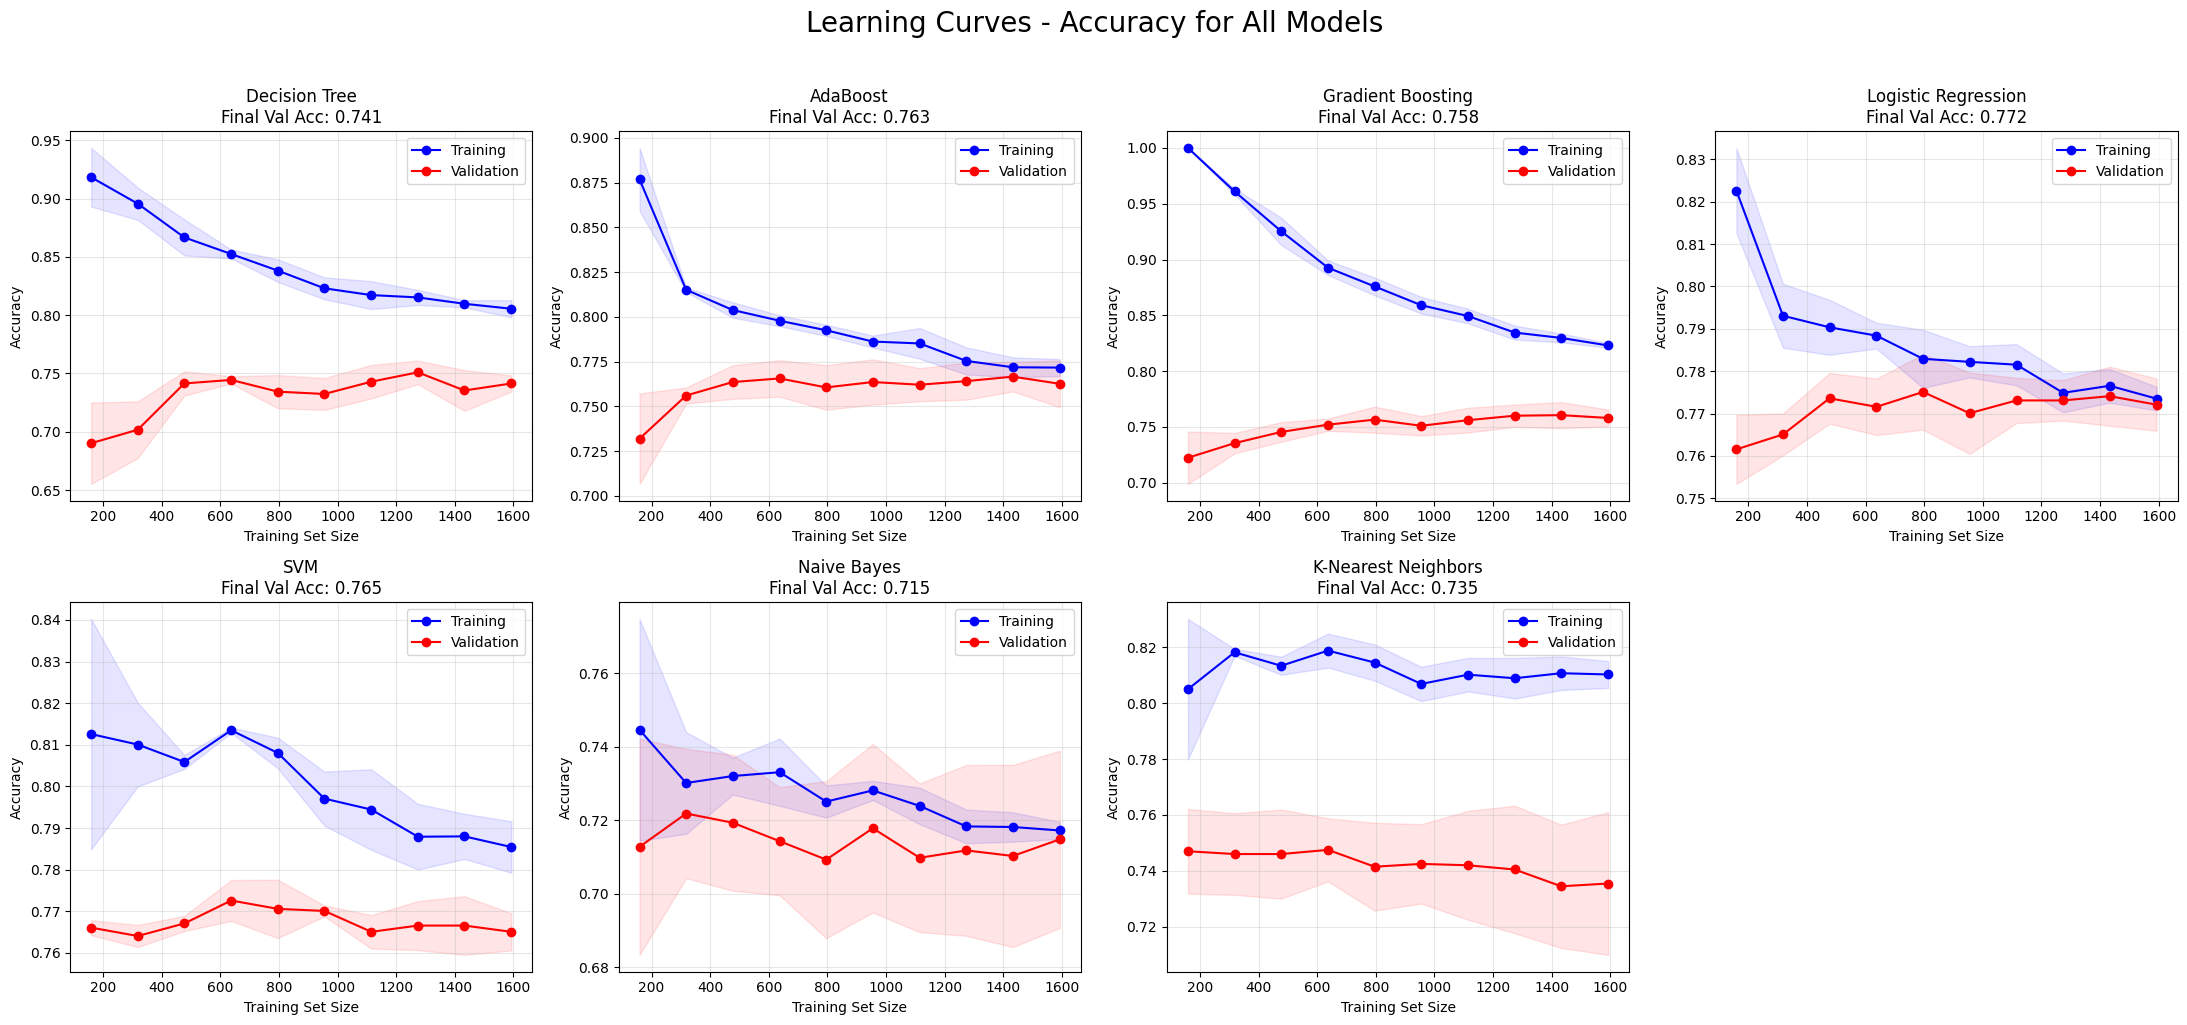


📊 FINAL PERFORMANCE SUMMARY
              Model  Test Accuracy  Test ROC  Train Accuracy
           AdaBoost         0.7735    0.6539          0.7736
Logistic Regression         0.7715    0.6562          0.7726
                SVM         0.7675    0.6231          0.7846
  Gradient Boosting         0.7535    0.6400          0.8153
K-Nearest Neighbors         0.7455    0.5768          0.8117
      Decision Tree         0.7435    0.6495          0.8057
        Naive Bayes         0.6954    0.6184          0.7159


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Your data (use selected_features)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Fix data types
def fix_data_types(X):
    X_fixed = X.copy()
    for col in X.columns:
        X_fixed[col] = pd.to_numeric(X_fixed[col], errors='coerce').fillna(0)
    return X_fixed

X_train_fixed = fix_data_types(X_train)
X_test_fixed = fix_data_types(X_test)

print("🎓 LEARNING CURVES FOR ALL MODELS")
print("="*60)

# Scale all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fixed)
X_test_scaled = scaler.transform(X_test_fixed)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# ==============================================
# LEARNING CURVES
# ==============================================
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

train_sizes = np.linspace(0.1, 1.0, 10)

for idx, (name, model) in enumerate(models.items()):
    print(f"Computing learning curve for {name}...")

    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    size_values, train_scores, val_scores = learning_curve(
        model, X_train_model, y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    axes[idx].plot(size_values, train_mean, 'o-', color='blue', label='Training')
    axes[idx].fill_between(size_values, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(size_values, val_mean, 'o-', color='red', label='Validation')
    axes[idx].fill_between(size_values, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    axes[idx].set_title(f'{name}\nFinal Val Acc: {val_mean[-1]:.3f}')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

    final_gap_pct = (train_mean[-1] - val_mean[-1]) * 100
    print(f"\n{name}: Final Train-Val Gap = {final_gap_pct:.2f}%")

    if final_gap_pct > 10:
        print("⚠️ WARNING: Possible Overfitting!")
    elif final_gap_pct > 5:
        print("⚡ WARNING: Mild Overfitting")
    else:
        print("✅ Good: No significant overfitting")

    model.fit(X_train_model, y_train)
    final_acc = accuracy_score(y_test, model.predict(X_test_model))
    print(f"{name:20} | Train Acc: {train_mean[-1]:.3f} | Val Acc: {val_mean[-1]:.3f} | Test Acc: {final_acc:.3f}")

# Remove the unused 8th subplot so only 7 plots remain
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Learning Curves - Accuracy for All Models', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# SUMMARY TABLE
# ==============================================
results = []
for name, model in models.items():
    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_test_model)

    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test ROC': roc_auc_score(y_test, model.predict_proba(X_test_model)[:, 1]),
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_model))
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n📊 FINAL PERFORMANCE SUMMARY")
print("="*50)
print(results_df.round(4).to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ==============================
# MODEL DICTIONARY
# ==============================
models_dict = {
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# ==============================
# OVERFITTING CHECK FUNCTION
# ==============================
def quick_overfit_check_classification(models_dict, X_train, X_test, y_train, y_test):
    results = []

    # Proper scaling: fit only on training data, then transform both
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models_dict.items():
        print(f"Training {name}...")

        # Fit model on scaled training data
        model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        # Accuracy
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        # ROC-AUC (binary safe)
        auc_info = ""
        if hasattr(model, "predict_proba"):
            try:
                train_proba = model.predict_proba(X_train_scaled)[:, 1]
                test_proba = model.predict_proba(X_test_scaled)[:, 1]

                train_auc = roc_auc_score(y_train, train_proba)
                test_auc = roc_auc_score(y_test, test_proba)
                auc_gap = train_auc - test_auc

                auc_info = f" | AUC Gap: {auc_gap:.3f}"
            except:
                pass

        # Overfitting status
        if gap > 0.08:
            status = "🔴 OVERFITTING!"
        elif gap > 0.03:
            status = "🟡 Moderate"
        else:
            status = "🟢 Good"

        # Store results
        results.append({
            'Model': name,
            'Train Acc': round(train_acc, 3),
            'Test Acc': round(test_acc, 3),
            'Gap': round(gap, 3),
            'Status': status
        })

        print(f"{name:20} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f} {status}{auc_info}")

    # Summary table
    df_results = pd.DataFrame(results).sort_values('Test Acc', ascending=False)

    print("\n" + "="*70)
    print("📊 FINAL OVERFITTING SUMMARY")
    print("="*70)
    print(df_results.to_string(index=False))

    overfit_count = sum(df_results['Gap'] > 0.08)
    print(f"\n📊 SUMMARY: {overfit_count}/{len(models_dict)} models are OVERFITTING!")

    return df_results

# ==============================
# RUN CHECK ON YOUR DATA
# ==============================
results_df = quick_overfit_check_classification(
    models_dict, X_train, X_test, y_train, y_test
)

Training Decision Tree...
Decision Tree        | Train: 0.806 | Test: 0.743 | Gap: 0.062 🟡 Moderate | AUC Gap: 0.129
Training AdaBoost...
AdaBoost             | Train: 0.774 | Test: 0.774 | Gap: 0.000 🟢 Good | AUC Gap: 0.052
Training Gradient Boosting...
Gradient Boosting    | Train: 0.815 | Test: 0.754 | Gap: 0.062 🟡 Moderate | AUC Gap: 0.205
Training Logistic Regression...
Logistic Regression  | Train: 0.773 | Test: 0.772 | Gap: 0.001 🟢 Good | AUC Gap: 0.015
Training SVM...
SVM                  | Train: 0.785 | Test: 0.768 | Gap: 0.017 🟢 Good | AUC Gap: 0.252
Training Naive Bayes...
Naive Bayes          | Train: 0.716 | Test: 0.695 | Gap: 0.020 🟢 Good | AUC Gap: 0.037
Training K-Nearest Neighbors...
K-Nearest Neighbors  | Train: 0.812 | Test: 0.745 | Gap: 0.066 🟡 Moderate | AUC Gap: 0.256

📊 FINAL OVERFITTING SUMMARY
              Model  Train Acc  Test Acc   Gap     Status
           AdaBoost      0.774     0.774 0.000     🟢 Good
Logistic Regression      0.773     0.772 0.001     🟢 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# Scale once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

for name, model in models_dict.items():
    print(f"Evaluating {name}...")

    # Use scaled data for ALL models
    X_fit, X_eval = X_train_scaled, X_test_scaled

    # Fit model
    model.fit(X_fit, y_train)

    # Predict class
    y_pred = model.predict(X_eval)

    # Predict probability / score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_eval)
    else:
        y_prob = None

    results.append({
        'Model': name,
        'Test Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'F1 Score (%)': round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'ROC-AUC (%)': round(roc_auc_score(y_test, y_prob) * 100, 2) if y_prob is not None else None
    })

results_df = pd.DataFrame(results)

print("\n📊 SIMPLE EVALUATION TABLE (Percentage)")
print(results_df.to_string(index=False))

Evaluating Decision Tree...
Evaluating AdaBoost...
Evaluating Gradient Boosting...
Evaluating Logistic Regression...
Evaluating SVM...
Evaluating Naive Bayes...
Evaluating K-Nearest Neighbors...

📊 SIMPLE EVALUATION TABLE (Percentage)
              Model  Test Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC (%)
      Decision Tree              74.35          32.26        8.55         13.51        64.95
           AdaBoost              77.35          66.67        6.84         12.40        65.39
  Gradient Boosting              75.35          39.29        9.40         15.17        64.00
Logistic Regression              77.15          60.00        7.69         13.64        65.62
                SVM              76.75          55.56        4.27          7.94        62.31
        Naive Bayes              69.54          33.64       30.77         32.14        61.84
K-Nearest Neighbors              74.55          38.64       14.53         21.12        57.68


# Adaboost -77.4%, 66.7%, 65.4%, but 6%,12%